<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td  style="border: none!important;">
        <img width=230 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                <h1 align=center><font size=5 color="#045F5F"> <b>Project 3</b><br><br>Alireza Karimi</i></font></h1>
                </td>
                <td style="border: none!important;">
        <img width=300 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from IPython.display import Image

In [ ]:
for i in range(1,40):
  display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/Teacher_Slides/Slide{i}.JPG'))

Output hidden; open in https://colab.research.google.com to view.

# A)

# Value Iteration

1. **Initialization**:
   - Start with an initial value function $V_1$. This can be initialized arbitrarily.

2. **Value Iteration Process**:
   - Iterate through the following steps until convergence:
     
     $V_{i+1}(s) = \max_a \sum_{s'} P(s'|s,a) [R(s,a,s') + \gamma V_i(s')]$

     - Update $V_{i+1}(s)$ to be the maximum expected return (value) achievable from state $s$ under all possible actions $a$, considering the current value function $V_i$.
     - $\gamma$ is the discount factor that trades off immediate rewards versus future rewards.
     - $P(s'|s,a)$ is the transition probability to state $s'$ when taking action $a$ in state $s$.
     - $R(s,a,s')$ is the immediate reward received after transitioning from state $s$ to state $s'$ by taking action $a$.

3. **Extracting the Optimal Policy**:
   - Once $V_i$ converges to $V^*$, the optimal value function, the optimal policy $\pi^*$ can be derived as:$\pi^*(s) = \arg\max_a \sum_{s'} P(s'|s,a) [R(s,a,s') + \gamma V^*(s')]$

### Explanation:

- **Value Iteration Sequence**: The notation $V_1 \rightarrow V_2 \rightarrow V_3 \rightarrow \ldots \rightarrow V^* \rightarrow \pi^*$ represents the iterative process of Value Iteration:
  - $V_i$: Value function at iteration $i$.
  - $V^*$: Optimal value function obtained after convergence.
  - $\pi^*$: Optimal policy derived from $V^*$.

- **Process**: Value Iteration updates the value function iteratively by maximizing over all possible actions from each state until convergence. Once the value function converges to $V^*$, the optimal policy $\pi^*$ is determined by selecting actions that maximize the expected return based on $V^*$.


# Policy iteration


1. **Initialization**:
   - Start with an initial policy $\pi_1$.

2. **Policy Evaluation**:
   - Evaluate the value function $V^{\pi_i}$ for the current policy $\pi_i$:

     $V^{\pi_i}(s) = \sum_{a} \pi_i(a|s)( \sum_{s'} P(s'|s,a) [R(s,a,s') + \gamma V^{\pi_i}(s')])$
   - This step computes $V^{\pi_i}(s)$ for all states $s$.
  - Each $\pi_i(a|s)$ represents the probability of taking action $a$ in state $s$.
   - $\gamma$ is the discount factor that trades off immediate rewards versus future rewards.
   - $P(s'|s,a)$ is the transition probability to state $s'$ when taking action $a$ in state $s$.
   - $R(s,a,s')$ is the immediate reward received after transitioning from state $s$ to state $s'$ by taking action $a$.

3. **Policy Improvement**:
   - Improve the policy $\pi_i$ to get $\pi_{i+1}$:
   
     $\pi_{i+1}(s) = \arg\max_a \sum_{s'} P(s'|s,a) [R(s,a,s') + \gamma V^{\pi_i}(s')]$
   - Update $\pi_{i+1}$ to be greedy with respect to $V^{\pi_i}$.

4. **Iterate**:
   - Repeat Steps 2 and 3 until convergence: $\pi_1 \rightarrow V^{\pi_1} \rightarrow \pi_2 \rightarrow V^{\pi_2} \rightarrow \ldots \rightarrow \pi^* \rightarrow V^{\pi^*} \rightarrow \pi^*$
   - Here, $\pi^*$ and $V^{\pi^*}$ denote the optimal policy and its corresponding optimal value function.

### Explanation:

- **Policy Iteration Sequence**: The notation $\pi_1 \rightarrow V^{\pi_1} \rightarrow \pi_2 \rightarrow V^{\pi_2} \rightarrow \ldots \rightarrow \pi^* \rightarrow V^{\pi^*} \rightarrow \pi^*$ represents the iterative process of Policy Iteration:
  - $\pi_i$: Policy at iteration $i$.
  - $V^{\pi_i}$: Value function corresponding to policy $\pi_i$.
  - $\pi_{i+1}$: Improved policy derived from $V^{\pi_i}$.
  - $\pi^*$: Optimal policy obtained after convergence.
  - $V^{\pi^*}$: Optimal value function corresponding to $\pi^*$.


## **Example:**

### States and Actions
- **States**: $A, B, C, D$

```
A  |  B
_______
C  |  D

```
- **Actions**:
  - Left/Right
  - Up/Down

### Transition Probabilities and Rewards
- **Left/Right**:
  - $A \xrightarrow{\text{Right}} B$: Reward = +1, Probability = 1
  - $B \xrightarrow{\text{Left}} A$: Reward = -1, Probability = 1
  - $C \xrightarrow{\text{Right}} D$: Reward = +1, Probability = 1
  - $D \xrightarrow{\text{Left}} C$: Reward = -1, Probability = 1

- **Up/Down**:
  - $A \xrightarrow{\text{Down}} C$: Reward = 0, Probability = 1
  - $C \xrightarrow{\text{Up}} A$: Reward = 0, Probability = 1
  - $B \xrightarrow{\text{Down}} D$: Reward = 0, Probability = 1
  - $D \xrightarrow{\text{Up}} B$: Reward = 0, Probability = 1

### Initialization
- Initial policy $\pi_1$:
  - $\pi_1(A) = \text{Right}$
  - $\pi_1(B) = \text{Left}$
  - $\pi_1(C) = \text{Right}$
  - $\pi_1(D) = \text{Left}$

- Initial value function $V(s) = 0$ for all $s$.

### Policy Evaluation
Evaluate the value function $V^{\pi_1}(s)$ for the current policy $\pi_1$:

For state $A$:

$V(A) = \sum_{a} \pi_1(a|A) \left( \sum_{s'} P(s'|A,a) [R(A,a,s') + \gamma V(s')] \right)$

Since $\pi_1(\text{Right}|A) = 1$ and $P(B|A,\text{Right}) = 1$:
$V(A) = 1 \cdot \left[ 1 + \gamma V(B) \right]$

$V(A) = 1 + \gamma V(B)$

For state $B$:
$V(B) = \sum_{a} \pi_1(a|B) \left( \sum_{s'} P(s'|B,a) [R(B,a,s') + \gamma V(s')] \right)$

Since $\pi_1(\text{Left}|B) = 1$ and $P(A|B,\text{Left}) = 1$:
$V(B) = 1 \cdot \left[ -1 + \gamma V(A) \right]$

$V(B) = -1 + \gamma V(A)$


For state $C$:
$V(C) = \sum_{a} \pi_1(a|C) \left( \sum_{s'} P(s'|C,a) [R(C,a,s') + \gamma V(s')] \right)$

Since $\pi_1(\text{Right}|C) = 1$ and $P(D|C,\text{Right}) = 1$:
$V(C) = 1 \cdot \left[ 1 + \gamma V(D) \right]$

$V(C) = 1 + \gamma V(D)$


For state $D$:
$V(D) = \sum_{a} \pi_1(a|D) \left( \sum_{s'} P(s'|D,a) [R(D,a,s') + \gamma V(s')] \right)$

Since $\pi_1(\text{Left}|D) = 1$ and $P(C|D,\text{Left}) = 1$:
$V(D) = 1 \cdot \left[ -1 + \gamma V(C) \right]$

$V(D) = -1 + \gamma V(C)$


Assume $\gamma = 0.9$.

Solve these linear equations:
1. $ V(A) = 1 + 0.9 V(B) $
2. $ V(B) = -1 + 0.9 V(A) $
3. $ V(C) = 1 + 0.9 V(D) $
4. $ V(D) = -1 + 0.9 V(C) $

Substitute 2 into 1:
$V(A) = 1 + 0.9(-1 + 0.9 V(A))$

$V(A) = 1 - 0.9 + 0.81 V(A)$

$V(A) - 0.81 V(A) = 0.1$

$0.19 V(A) = 0.1$

$V(A) = \frac{0.1}{0.19} \approx 0.526$


$V(B) = -1 + 0.9 \cdot 0.526 \approx -0.526$


Substitute 4 into 3:
$V(C) = 1 + 0.9(-1 + 0.9 V(C))$

$V(C) = 1 - 0.9 + 0.81 V(C)$

$V(C) - 0.81 V(C) = 0.1$

$0.19 V(C) = 0.1$

$V(C) = \frac{0.1}{0.19} \approx 0.526$


$V(D) = -1 + 0.9 \cdot 0.526 \approx -0.526$


So, the value function is:

$V(A) \approx 0.526$

$V(B) \approx -0.526$

$V(C) \approx 0.526$

$V(D) \approx -0.526$


### Policy Improvement
Update the policy using:
$\pi_{i+1}(s) = \arg\max_a \sum_{s'} P(s'|s,a) [R(s,a,s') + \gamma V(s')]$


For state $A$:
- Evaluate possible actions:
  - Right: $ 1 + 0.9 V(B) = 1 + 0.9 \cdot (-0.526) \approx 1 - 0.473 = 0.527 $
  - Down: $ 0 + 0.9 V(C) = 0 + 0.9 \cdot 0.526 \approx 0.473 $

Since $0.527 > 0.473$:
$\pi_{i+1}(A) = \text{Right}$


For state $B$:
- Evaluate possible actions:
  - Left: $ -1 + 0.9 V(A) = -1 + 0.9 \cdot 0.526 \approx -1 + 0.473 = -0.527 $
  - Down: $ 0 + 0.9 V(D) = 0 + 0.9 \cdot (-0.526) \approx -0.473 $

Since $-0.473 > -0.527$:
$\pi_{i+1}(B) = \text{Down}$


For state $C$:
- Evaluate possible actions:
  - Right: $ 1 + 0.9 V(D) = 1 + 0.9 \cdot (-0.526) \approx 1 - 0.473 = 0.527 $
  - Up: $ 0 + 0.9 V(A) = 0 + 0.9 \cdot 0.526 \approx 0.473 $

Since $0.527 > 0.473$:
$\pi_{i+1}(C) = \text{Right}$


For state $D$:
- Evaluate possible actions:
  - Left: $ -1 + 0.9 V(C) = -1 + 0.9 \cdot 0.526 \approx -1 + 0.473 = -0.527 $
  - Up: $ 0 + 0.9 V(B) = 0 + 0.9 \cdot (-0.526) \approx -0.473 $

Since $-0.473 > -0.527$:
$\pi_{i+1}(D) = \text{Up}$


### New Policy
- $\pi_{i+1}(A) = \text{Right}$
- $\pi_{i+1}(B) = \text{Down}$
- $\pi_{i+1}(C) = \text{Right}$
- $\pi_{i+1}(D) = \text{Up}$

### Repeat until Convergence
- Perform policy evaluation and improvement iteratively until the policy stabilizes and no longer changes.


This example was created by [ChatGPT](https://chatgpt.com/)

#**B)**

# **Explain these codes**

# 1. Import dependencies

In [ ]:
# For generating random numbers
import random

# Importing the gym library for creating and working with OpenAI Gym environments
import gym

# Importing numpy, a powerful library for numerical computing
import numpy as np

# Importing deque from collections, which is a double-ended queue that allows fast appends and pops
# To add and remove elements from both ends
from collections import deque

# Importing Sequential model from Keras, a high-level neural networks API
from tensorflow.keras.models import Sequential

# A fully connected layer
from tensorflow.keras.layers import Dense

# Optimization algorithm
from tensorflow.keras.optimizers import Nadam

# Optimization algorithm
from keras.optimizers import Adam

# For displaying HTML content
from IPython.display import HTML

# For interacting with the operating system
import os


Sure, let's break down and explain the provided `train` method code in detail:

```python
def train(self, batch_size):
    # sample a minibatch from memory
    minibatch = random.sample(self.memory, batch_size)

    # extract data for each minibatch sample
    for state, action, reward, next_state, done in minibatch:
        if done:
            target = reward
        else: # if not done, then predict future discounted reward
            target = (reward +
                      self.gamma * # (target) = reward + (discount rate gamma) *
                      np.max(self.model.predict(next_state, verbose=0)[0])) # (maximum target Q based on future action a')

        # approximately map current state to future discounted reward
        target_f = self.model.predict(state, verbose=0)
        target_f[0][action] = target

        # single epoch of training with x=state, y=target_f; fit decreases loss btwn target_f and y_hat
        self.model.fit(state, target_f, epochs=1, verbose=0)

    if self.epsilon > self.epsilon_min:
        self.epsilon *= self.epsilon_decay
```

### Detailed Breakdown

#### 1. Sampling a Minibatch

```python
minibatch = random.sample(self.memory, batch_size)
```

- **Purpose**: Randomly sample a batch of experiences (state, action, reward, next_state, done) from the agent's memory.
- **Reason**: Training the neural network on a random sample helps to break the correlation between consecutive experiences, which improves training stability and performance.

#### 2. Iterating Through the Minibatch

```python
for state, action, reward, next_state, done in minibatch:
```

- **Purpose**: Loop through each experience in the minibatch to update the Q-values based on the agent's experiences.

#### 3. Calculating the Target Value
When is the game done:

In the CartPole game implemented in Python, the game is considered "done" (i.e., the episode ends) under two main conditions:

1. **Pole Angle**: If the absolute angle of the pole with respect to the vertical axis exceeds a certain threshold, typically $\pm 12^\circ$ or $\pm 15^\circ$, the episode is considered terminated.

2. **Cart Position**: If the absolute position of the cart moves outside of predefined bounds on the track, usually $\pm 2.4$ units from the center, the episode is terminated.

```python
if done:
    target = reward
else:
    target = (reward +
              self.gamma *  # (target) = reward + (discount rate gamma) *
              np.max(self.model.predict(next_state, verbose=0)[0]))  # (maximum target Q based on future action a')
```

- **If `done`**:
  - **Condition**: If the episode has ended (`done` is `True`), set the target to the received reward.
  - **Reason**: When the episode ends, there are no future rewards to consider.
- **If `not done`**:
  - **Condition**: If the episode is not done (`done` is `False`), calculate the target as the reward plus the discounted maximum Q-value of the next state.
  - **Formula**: $ \text{target} = \text{reward} + \gamma \times \max(Q(\text{next_state})) $
  - **Purpose**: Estimate the future rewards, considering the best possible action from the next state.
  - **Reason**: This follows the Bellman equation, which is fundamental in Q-learning, to update the value of the current state-action pair.

----
$\text{target} = \begin{cases}
\text{reward} & \text{if } \text{done} \\
\text{reward} + \gamma \cdot \max(Q(s', a')) & \text{if not done}
\end{cases}$

Components:
- $\text{reward}$: The immediate reward received.
- $\gamma$ (gamma): The discount factor for future rewards.
- $Q(s', a')$: The predicted Q-value for the next state $s'$ and action $a'$.
- $\max(Q(s', a'))$: The maximum Q-value for the next state over all possible actions.
- $\text{done}$: A boolean indicating whether the episode has ended.
----
#### 4. Predicting Q-values and Updating

```python
target_f = self.model.predict(state, verbose=0)
target_f[0][action] = target
```

- **Predict Q-values**:
  - `target_f = self.model.predict(state, verbose=0)`: Predict the Q-values **for the current state** using the neural network.
  - **Purpose**: Get the current estimate of the Q-values for all actions in the current state.
- **Update the Q-value**:
  - `target_f[0][action] = target`: Update the Q-value for the action taken with the calculated target.( [0] is for the first and our only state)
  - **Purpose**: Update the Q-value of the specific action taken with the new knowledge (experience) based on the observed target value.


**Actually we want to update the weights and biases of our model based on the new upadated Q-values that we've calculated.**

#### 5. Training the Model

```python
self.model.fit(state, target_f, epochs=1, verbose=0)
```

- **Single Epoch Training**:
  - `self.model.fit(state, target_f, epochs=1, verbose=0)`: Train the model for one epoch to fit the state to the updated Q-value (target_f).
  - **Purpose**: Minimize the loss between the predicted Q-values and the target Q-values, updating the neural network's weights accordingly.

#### 6. Reducing the Exploration Rate

```python
if self.epsilon > self.epsilon_min:
    self.epsilon *= self.epsilon_decay
```

- **Condition**: Check if the current exploration rate (epsilon) is greater than the minimum exploration rate (epsilon_min).
- **Purpose**: Gradually reduce the exploration rate (epsilon) to favor exploitation over time as the agent learns.
- **Formula**: Multiply epsilon by the decay factor (`epsilon_decay`).
- **Reason**: This ensures the agent explores less as it becomes more confident in its learned policy, balancing exploration and exploitation.

### Summary

- **Sampling**: Randomly selects a batch of experiences from memory to break correlations and dependencies.
- **Target Calculation**: Uses the Bellman equation to update the Q-value for the taken action.
- **Prediction and Update**: Predicts current Q-values, updates them with the target, and trains the model to fit the updated Q-values.
- **Exploration Rate Adjustment**: Reduces the exploration rate over time to shift from exploration to exploitation.

This method effectively updates the agent's Q-values and refines its policy through reinforcement learning, allowing it to learn optimal actions to maximize cumulative rewards over time.

In [ ]:
def train(self, batch_size):
    # sample a minibatch from memory
    minibatch = random.sample(self.memory, batch_size)

    # extract data for each minibatch sample
    for state, action, reward, next_state, done in minibatch:
        if done:
            target = reward
        else: # if not done, then predict future discounted reward
            target = (reward +
                      self.gamma * # (target) = reward + (discount rate gamma) *
                      np.max(self.model.predict(next_state, verbose=0)[0])) # (maximum target Q based on future action a')

        # approximately map current state to future discounted reward
        target_f = self.model.predict(state, verbose=0)
        target_f[0][action] = target

        # single epoch of training with x=state, y=target_f; fit decreases loss btwn target_f and y_hat
        self.model.fit(state, target_f, epochs=1, verbose=0)

    if self.epsilon > self.epsilon_min:
        self.epsilon *= self.epsilon_decay

# 2. Hyperparameters and initialise environment

In [ ]:
env = gym.make('CartPole-v0') # initialise environment

/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


States: the position, velocity, angle, and angular velocity of the pole

In [ ]:
state_size = env.observation_space.shape[0]
state_size

4

# 3. The agent can take two actions-right or left

1. Move left: Push the cart to the left.
2. Move right: Push the cart to the right.

In [ ]:
action_size = env.action_space.n
action_size


2

In [ ]:
batch_size = 32

# 4. Number of games that the agent is going to play

In [ ]:
n_episodes = 200

# 5. Storing the model output

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
output_dir = '/content/drive/MyDrive/Class note/cartpole'

In [ ]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Hyperparameter optimization using keras tuner

In [ ]:
!pip install keras-tuner -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.9 MB/s eta 0:00:00


In [ ]:
import keras_tuner

#Explanation of the provided code snippet:

```python
for e in range(n_episodes):
    # Iterate over episodes of gameplay

    state = env.reset()
    # Reset the environment and get the initial state
    state = np.reshape(state, [1, state_size])
    # Reshape the state to match the input shape of the neural network

    done = False
    time = 0  # Initialize time step counter for the episode

    while not done:
        # Continue the episode until termination

        action = agent.act(state)
        # Agent selects an action based on the current state
        # (e.g., move left or right in the Cartpole game)

        next_state, reward, done, _ = env.step(action)
        # Environment takes the action, returns next state, reward, and whether the episode is done

        reward = reward if not done else -10
        # If the episode terminates, penalize with a reward of -10

        next_state = np.reshape(next_state, [1, state_size])
        # Reshape the next state for compatibility with the neural network input

        agent.remember(state, action, reward, next_state, done)
        # Store the experience tuple (state, action, reward, next_state, done) in agent's memory

        state = next_state
        # Update the current state to the next state for the next time step

        if done:
            # If the episode ends
            print("episode: {}/{}, score: {}, e: {:.2}"
                  .format(e, n_episodes-1, time, agent.epsilon))
            # Print episode number, score (time steps survived), and agent's exploration rate (epsilon)

        time += 1
        # Increment the time step counter for the current episode

    if e >= int(0.9 * n_episodes):
        latest_scores[e - int(0.9 * n_episodes)] = time - 1 # Because of time += 1 at the end of the loop although it is done
        # Store the score (time steps survived) of the last 10% episodes

    if len(agent.memory) > batch_size:
        agent.train(batch_size)
        # Train the agent by replaying experiences stored in memory using minibatch training

    if e % 50 == 0:
        agent.save(output_dir + "weights_" + '{:04d}'.format(e) + ".hdf5")
        # Save the weights of the agent's neural network every 50 episodes
```

### Explanation:

1. **Episode Loop (`for e in range(n_episodes)`)**:
   - Iterates through the specified number of episodes (`n_episodes`).

2. **Initialize State (`state = env.reset()`)**:
   - Resets the environment to its initial state and retrieves the initial observation (`state`).

3. **Action Selection (`action = agent.act(state)`)**:
   - The agent selects an action based on the current state (`state`).

4. **Environment Interaction (`next_state, reward, done, _ = env.step(action)`)**:
   - Executes the selected action (`action`) in the environment (`env`), receiving the next state (`next_state`), reward (`reward`), and an indicator if the episode is done (`done`).

5. **Reward Handling (`reward = reward if not done else -10`)**:
   - Adjusts the received reward to penalize the agent if the episode terminates (`done`).

6. **Experience Replay (`agent.remember(state, action, reward, next_state, done)`)**:
   - Stores the experience tuple `(state, action, reward, next_state, done)` in the agent's memory for later training.

7. **State Update (`state = next_state`)**:
   - Updates the current state to the observed next state for the next time step.

8. **Episode End Check (`if done`)**:
   - Checks if the episode has ended (`done`). If true, prints episode statistics including the episode number (`e`), score (`time`), and the agent's exploration rate (`epsilon`).

9. **Score Tracking (`latest_scores[e - int(0.9 * n_episodes)] = time - 1`)**:
   - Records the score (time steps survived) of the last 10% of episodes.

10. **Training (`agent.train(batch_size)`)**:
    - Trains the agent using experiences stored in memory if the memory size exceeds `batch_size`.

11. **Model Saving (`agent.save(output_dir + "weights_" + '{:04d}'.format(e) + ".hdf5")`)**:
    - Saves the weights of the agent's neural network every 50 episodes to the specified output directory (`output_dir`).

This code snippet demonstrates a typical reinforcement learning loop where an agent interacts with an environment, collects experiences, and learns to improve its policy (action selection strategy) over multiple episodes of gameplay.

In [ ]:
from kerastuner import RandomSearch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, Nadam
import tensorflow as tf
from collections import deque
import numpy as np
import random

class Tuner(keras_tuner.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        agent = self.build(trial.hyperparameters, *args)
        score = self.fit(agent, **kwargs)
        return score

    def build(self, hp, *args):
        num_layers = hp.Int("num_layers", 1, 3)  # Optimize number of layers
        layers_units = [hp.Int("units_1", min_value=32, max_value=128, step=32)]
        for i in range(num_layers - 1):
            layers_units.append(hp.Int(f"units_{i+2}", min_value=32, max_value=128, step=32))

        return DQNAgent(*args,
            num_layers=num_layers,
            layers_units=layers_units,
            gamma=hp.Float("gamma", min_value=0.8, max_value=0.99, step=0.01),
            epsilon=hp.Float("epsilon", min_value=0.1, max_value=1.0, step=0.1),
            epsilon_decay=hp.Float("epsilon_decay", min_value=0.90, max_value=0.999, step=0.01),
            learning_rate=hp.Float("learning_rate", min_value=1e-5, max_value=1e-2, sampling="log"),
            activation=hp.Choice("activation", ["relu", "sigmoid", "tanh"])
        )
    def fit(self, agent, n_episodes, batch_size):
        latest_scores = np.zeros(int(0.1 * n_episodes))

        for e in range(n_episodes): # iterate over episodes of gameplay

            state = env.reset() # reset state and get four random states.
            state = np.reshape(state, [1, state_size]) # To pass this to the NN.

            done = False
            time = 0 # goal is to keep pole upright as long as possible.
            while not done:
            # This while loop ends if we get to 200 timesteps or the pole falls, or cart disappears from the screen.
                action = agent.act(state) # Given the state, the agent takes an action (move cart left or right).
                next_state, reward, done, _ = env.step(action) # agent interacts with env, gets feedback; 4 state data points.
                reward = reward if not done else -10 # reward +1 for each additional frame with pole upright and -10 for ending the game.
                next_state = np.reshape(next_state, [1, state_size]) # To pass this to the NN.
                agent.remember(state, action, reward, next_state, done) # To remember the previous timestep's state, actions, reward, etc.
                state = next_state # set current state to the current next state for the next while loop
                if done: # if episode ends:
                    print("episode: {}/{}, score: {}, e: {:.2}" # print the episode's score and agent's epsilon
                        .format(e, n_episodes-1, time, agent.epsilon))
                time += 1

            if e >= int(0.9*n_episodes):
                latest_scores[e - int(0.9*n_episodes)] = time - 1

            if len(agent.memory) > batch_size:
                agent.train(batch_size) # train the agent by replaying the experiences of the episode

            # after 50 episodes, we save our weights.

            if e % 50 == 0:
                agent.save(output_dir + "weights_"
                        + '{:04d}'.format(e) + ".hdf5")

        return sum(latest_scores) / len(latest_scores)


<ipython-input-15-4d51fbcbe10a>:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import RandomSearch


In [ ]:
###########################################################################################################
class DQNAgent:
    def __init__(self, state_size, action_size, num_layers, layers_units, gamma, epsilon, epsilon_decay, learning_rate, activation):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = 0.01
        self.learning_rate = learning_rate
        self.model = self._build_model(num_layers, layers_units, activation)

    def _build_model(self, num_layers, layers_units, activation):
        model = Sequential()
        model.add(Dense(layers_units[0], activation=activation, input_dim=self.state_size))
        for units in layers_units[1:]:
            model.add(Dense(units, activation=activation))
        model.add(Dense(self.action_size, activation='linear'))
        model.compile(loss='mse', optimizer=Nadam(learning_rate=self.learning_rate))
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train(self, batch_size):
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                target = (reward + self.gamma * np.amax(self.model.predict(next_state, verbose=0)[0]))
            target_f = self.model.predict(state, verbose=0)
            target_f[0][action] = target
            self.model.fit(state, target_f, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])

    def save(self, name):
        self.model.save_weights(name)

    def load(self, name):
        self.model.load_weights(name)


#### 8. Search the state space with 5 kinds of different hyperparameter

In [ ]:
tuner = Tuner(max_trials=5,
              overwrite=True,
              objective=keras_tuner.Objective('score', direction="max"))

tuner.search(state_size, action_size, n_episodes=200, batch_size=32)

Trial 5 Complete [00h 02m 03s]
score: 8.5

Best score So Far: 11.0
Total elapsed time: 00h 10m 11s


In [ ]:
tuner.search_space_summary()

Search space summary
Default search space size: 9
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
gamma (Float)
{'default': 0.8, 'conditions': [], 'min_value': 0.8, 'max_value': 0.99, 'step': 0.01, 'sampling': 'linear'}
epsilon (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 1.0, 'step': 0.1, 'sampling': 'linear'}
epsilon_decay (Float)
{'default': 0.9, 'conditions': [], 'min_value': 0.9, 'max_value': 0.999, 'step': 0.01, 'sampling': 'linear'}
learning_rate (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh'], 'ordered': False}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step':

In [ ]:
tuner.results_summary()

Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="score", direction="max")

Trial 0 summary
Hyperparameters:
num_layers: 1
units_1: 32
gamma: 0.8
epsilon: 0.1
epsilon_decay: 0.9
learning_rate: 1e-05
activation: relu
Score: 11.0

Trial 3 summary
Hyperparameters:
num_layers: 3
units_1: 64
gamma: 0.92
epsilon: 0.4
epsilon_decay: 0.9
learning_rate: 0.007001122619834789
activation: sigmoid
units_2: 96
units_3: 128
Score: 10.0

Trial 2 summary
Hyperparameters:
num_layers: 1
units_1: 64
gamma: 0.81
epsilon: 0.2
epsilon_decay: 0.92
learning_rate: 6.065868895306024e-05
activation: sigmoid
units_2: 32
units_3: 64
Score: 9.0

Trial 4 summary
Hyperparameters:
num_layers: 3
units_1: 64
gamma: 0.8600000000000001
epsilon: 0.4
epsilon_decay: 0.96
learning_rate: 7.255142492595754e-05
activation: sigmoid
units_2: 96
units_3: 96
Score: 8.5

Trial 1 summary
Hyperparameters:
num_layers: 3
units_1: 32
gamma: 0.8300000000000001
epsilon: 0.1
epsilon_decay: 0.9400000000000001


#**References**

## 1.Jon Krohn,Machine Vision, GANs, and Deep Reinforcement Learning

## 2.Deep Q-Learning Network with Keras and OpenAI Gym, based on Keon Kim's code

# **C)**

# 1. Import dependencies

In [ ]:
import random
import numpy as np

# for creating the environment
import gym

# for making the memory
from collections import deque

# for making the Neural Network
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# for creating the model weights directory
import os

# for ignoring warnings
import warnings
# warnings.filterwarnings("ignore")

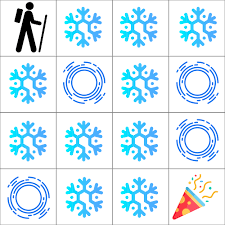

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/frozen_lake.png', width = 600))

#### Create the environment
- Here we'll create the FrozenLake environment.
- OpenAI Gym is a library **composed of many environments that we can use to train our agents.**
- In our case we choose to use Frozen Lake.

Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. The player may not always move in the intended direction due to the slippery nature of the frozen lake.

**Action Space**: The action shape is (1,) in the range {0, 3} indicating which direction to move the player.
* 0: Move left
* 1: Move down
* 2: Move right
* 3: Move up

**Observation Space**: The observation is a value representing the player’s current position as current_row * nrows + current_col (where both the row and col start at 0).

**Rewards**: Reward schedule:
* Reach goal: +1
* Reach hole: 0
* Reach frozen: 0

**Episode End**: The episode ends if the following happens:
* Termination:
    1. The player moves into a hole.
    2. The player reaches the goal.
* Truncation (when using the time_limit wrapper):
    1. The length of the episode is 100

# 2. Initialise environment

In [ ]:
# initialise environment
env = gym.make('FrozenLake-v1')

/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


# 3. Hyperparameters

In [ ]:
state_size = env.observation_space.n
state_size

16

# 4. The agent can take four actions-right, left, up or down

In [ ]:
action_size = env.action_space.n
action_size

4

In [ ]:
batch_size = 32

# 5. Number of games that the agent is going to play

In [ ]:
n_episodes = 200

# 6. Storing the model output

In [ ]:
output_dir = '/content/drive/MyDrive/Class note/FrozenLake'

In [ ]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 7. Define agent

In [ ]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000) # deque is like list and we can append elements to it.
        self.gamma = 0.95 # discount rate.
        self.epsilon = 1.0 # exploration rate: how much to act randomly.
        self.epsilon_decay = 0.995 # decrease number of random explorations as the agent's performance improves.
        self.epsilon_min = 0.01 # minimum amount of random exploration permitted.
        self.learning_rate = 0.001 # learning rate.
        self.model = self._build_model() # This is a private method

    def _build_model(self):
        # neural net to approximate Q-value function:
        model = Sequential([
            Dense(32, activation='relu', input_dim=self.state_size), # 1st hidden layer; states as input
            Dense(32, activation='relu'), # 2nd hidden layer
            Dense(self.action_size, activation='linear') # 4 actions, so 4 output neurons(L/R/D/U)
        ])

        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def remember(self, state, action, reward, next_state, done):
        # list of previous experiences, enabling re-training later
        self.memory.append((state, action, reward, next_state, done))

    # method that trains NN with experiences sampled from memory
    def train(self, batch_size):
        # sample a minibatch from memory
        minibatch = random.sample(self.memory, batch_size)

        # extract data for each minibatch sample
        for state, action, reward, next_state, done in minibatch:
            if done:
                target = reward
            else: # if not done, then predict future discounted reward
                target = (reward +
                          self.gamma * # (target) = reward + (discount rate gamma) *
                          np.max(self.model.predict(next_state, verbose=0)[0])) # (maximum target Q based on future action a')

            # approximately map current state to future discounted reward
            target_f = self.model.predict(state, verbose=0)
            target_f[0][action] = target

            # single epoch of training with x=state, y=target_f; fit decreases loss btwn target_f and y_hat
            self.model.fit(state, target_f, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def act(self, state):
        # if acting randomly, take random action
        if np.random.rand() <= self.epsilon:
            return random.randint(0, self.action_size - 1)

        # if not acting randomly, predict reward value based on current state
        act_values = self.model.predict(state, verbose=0)

        # pick the action that will give the highest reward (i.e., go left or down or right or up?)
        return np.argmax(act_values[0])

    def save(self, name):
        self.model.save_weights(name)

    def load(self, name):
        self.model.load_weights(name)

target calculation if not done:
$$V(s)=E[R^a_{ss'}+γV(s')]=E[R^a_{ss'}+γ \: max_aQ(s', a)]$$

# 8. initialise agent

In [ ]:
agent = DQNAgent(state_size, action_size)

# 9. Interact with environment

Certainly! Let's go through the provided code lines step by step. This code represents the main training loop for a Deep Q-Learning (DQN) agent interacting with an environment, likely using OpenAI's Gym.

### Explanation of the Code

#### Initial Setup
The code starts by iterating over a specified number of episodes:

```python
for episode in range(n_episodes):
    # reset state at start of each new episode of the game
    state = env.reset()
```

- **`for episode in range(n_episodes):`**: This loop iterates through each episode of gameplay.
- **`state = env.reset()`**: At the start of each episode, the environment is reset to its initial state.

#### State Representation (One-Hot Encoding)

```python
    # change the state number to One-hot implementation as the input of NN
    state_arr = np.zeros(state_size)
    state_arr[state] = 1
    state = np.reshape(state_arr, [1, state_size])
```

- **One-Hot Encoding**: The state is converted to a one-hot encoded vector suitable for neural network input.
  - **`state_arr = np.zeros(state_size)`**: Creates an array of zeros with a length equal to the state size.
  - **`state_arr[state] = 1`**: Sets the index corresponding to the state to 1.
  - **`state = np.reshape(state_arr, [1, state_size])`**: Reshapes the array to match the expected input shape for the neural network.

#### Initialize Time and Done Flag

```python
    time = 1
    done = False
```

- **`time = 1`**: Initializes the time step counter.
- **`done = False`**: Initializes the `done` flag, which indicates whether the episode has ended.

#### Main Loop: Interaction with the Environment

```python
    while not done:
        # env.render()

        # action is either 0 or 1 or 2 or 3 (left or down or right or up); decide one of them
        action = agent.act(state)

        # agent interacts with env, gets feedback; 16 state data points
        next_state, reward, done, _ = env.step(action)

        # reward = -1 if done and time<100 and reward==0 else 10*reward  # reward +1 for each additional frame with pole upright

        # change the number of next state to One-hot implementation as the input of NN
        next_state_arr = np.zeros(state_size)
        next_state_arr[next_state] = 1
        next_state = np.reshape(next_state_arr, [1, state_size])

        # remember the previous timestep's state, actions, reward, etc.
        agent.remember(state, action, reward, next_state, done)

        # set "current state" for upcoming iteration to the current next state
        state = next_state

        if done: # if episode ends:
            print(f'Episode: {episode:4}/{n_episodes} and step: {time:4}. reward {reward}, Eps: {float(agent.epsilon):.2}') # print the episode's score and agent's epsilon

        time += 1
```

- **`while not done:`**: Continue the loop until the episode ends (`done` is True).
- **`action = agent.act(state)`**: The agent selects an action based on the current state.
- **`next_state, reward, done, _ = env.step(action)`**: The environment responds to the action with the next state, reward, and a flag indicating if the episode has ended (`done`).

- **One-Hot Encoding for Next State**:
  - **`next_state_arr = np.zeros(state_size)`**: Creates an array of zeros with a length equal to the state size.
  - **`next_state_arr[next_state] = 1`**: Sets the index corresponding to the next state to 1.
  - **`next_state = np.reshape(next_state_arr, [1, state_size])`**: Reshapes the array to match the expected input shape for the neural network.

- **`agent.remember(state, action, reward, next_state, done)`**: The agent stores the experience (current state, action, reward, next state, done) in its memory.
- **`state = next_state`**: Updates the current state to the next state.
- **`if done:`**: If the episode has ended:
  - **`print(f'Episode: {episode:4}/{n_episodes} and step: {time:4}. reward {reward}, Eps: {float(agent.epsilon):.2}')`**: Print the episode number, time steps, reward, and exploration rate (epsilon).

- **`time += 1`**: Increment the time step counter.

#### Training the Agent

```python
    # train the agent by replaying the experiences of the episode
    if len(agent.memory) > batch_size:
        agent.train(batch_size)

    if episode % 50 == 0:
        agent.save(output_dir + "weights_" + '{:04d}'.format(episode) + ".hdf5")
```

- **Training Condition**:
  - **`if len(agent.memory) > batch_size:`**: Check if there are enough experiences in memory to form a batch.
  - **`agent.train(batch_size)`**: Train the agent using a batch of experiences sampled from memory.

- **Saving Model Weights**:
  - **`if episode % 50 == 0:`**: Every 50 episodes, save the model weights.
  - **`agent.save(output_dir + "weights_" + '{:04d}'.format(episode) + ".hdf5")`**: Save the model weights to a file.

### Summary

- **Episode Loop**: Iterates over a specified number of episodes.
- **State Initialization**: Resets the environment and one-hot encodes the initial state.
- **Main Interaction Loop**: The agent interacts with the environment by selecting actions, receiving feedback, and storing experiences.
- **Training and Saving**: The agent trains on experiences from memory if enough are available and periodically saves the model weights.

This code implements the core of a Deep Q-Learning (DQN) training loop, allowing the agent to learn from its interactions with the environment and improve its policy over time.

In [ ]:
# iterate over episodes of gameplay
for episode in range(n_episodes):

    # reset state at start of each new episode of the game
    state = env.reset()

    # change the state number to One-hot implementation as the input of NN
    state_arr = np.zeros(state_size)
    state_arr[state] = 1
    state= np.reshape(state_arr, [1, state_size])

    # time represents a frame of the episode
    time = 1
    done = False

    while not done:
        # env.render()

        # action is either 0 or 1 or 2 or 3 (left or down or right or up); decide one of them
        action = agent.act(state)

        # agent interacts with env, gets feedback; 16 state data points
        next_state, reward, done, _ = env.step(action)

        # reward = -1 if done and time<100 and reward==0 else 10*reward  # reward +1 for each additional frame with pole upright

        # change the number of next state to One-hot implementation as the input of NN
        next_state_arr = np.zeros(state_size)
        next_state_arr[next_state] = 1
        next_state = np.reshape(next_state_arr, [1, state_size])

        # remember the previous timestep's state, actions, reward, etc.
        agent.remember(state, action, reward, next_state, done)

        # set "current state" for upcoming iteration to the current next state
        state = next_state

        if done: # if episode ends:
            print(f'Episode: {episode:4}/{n_episodes} and step: {time:4}. reward {reward}, Eps: {float(agent.epsilon):.2}') # print the episode's score and agent's epsilon

        time += 1

    # train the agent by replaying the experiences of the episode
    if len(agent.memory) > batch_size:
        agent.train(batch_size)

    if episode % 50 == 0:
        agent.save(output_dir + "weights_" + '{:04d}'.format(episode) + ".hdf5")

Episode:    0/200 and step:    6. reward 0.0, Eps: 1.0
Episode:    1/200 and step:   14. reward 0.0, Eps: 1.0
Episode:    2/200 and step:   14. reward 0.0, Eps: 1.0
Episode:    3/200 and step:   11. reward 0.0, Eps: 0.99
Episode:    4/200 and step:    6. reward 0.0, Eps: 0.99
Episode:    5/200 and step:   15. reward 0.0, Eps: 0.99
Episode:    6/200 and step:   10. reward 0.0, Eps: 0.98
Episode:    7/200 and step:    7. reward 0.0, Eps: 0.98
Episode:    8/200 and step:   12. reward 0.0, Eps: 0.97
Episode:    9/200 and step:    2. reward 0.0, Eps: 0.97
Episode:   10/200 and step:    7. reward 0.0, Eps: 0.96
Episode:   11/200 and step:    2. reward 0.0, Eps: 0.96
Episode:   12/200 and step:   10. reward 0.0, Eps: 0.95
Episode:   13/200 and step:    5. reward 0.0, Eps: 0.95
Episode:   14/200 and step:    7. reward 0.0, Eps: 0.94
Episode:   15/200 and step:   12. reward 0.0, Eps: 0.94
Episode:   16/200 and step:    3. reward 0.0, Eps: 0.93
Episode:   17/200 and step:    6. reward 0.0, Eps: 

In [ ]:
# saved agents can be loaded with agent.load("./path/filename.hdf5")

source:

https://github.com/the-deep-learners/deep-learning-illustrated/blob/master/notebooks/cartpole_dqn.ipynb

https://colab.research.google.com/drive/16Zs4cKeZbuIB_5cJ2NGqKmrDFLDLAG1Y#scrollTo=x7AQlx-0xcy8

https://colab.research.google.com/drive/1sKWdhscgxCEqrmifWeWDsDsrAKkXeg1A?usp=sharing

# **Part2**

# A)

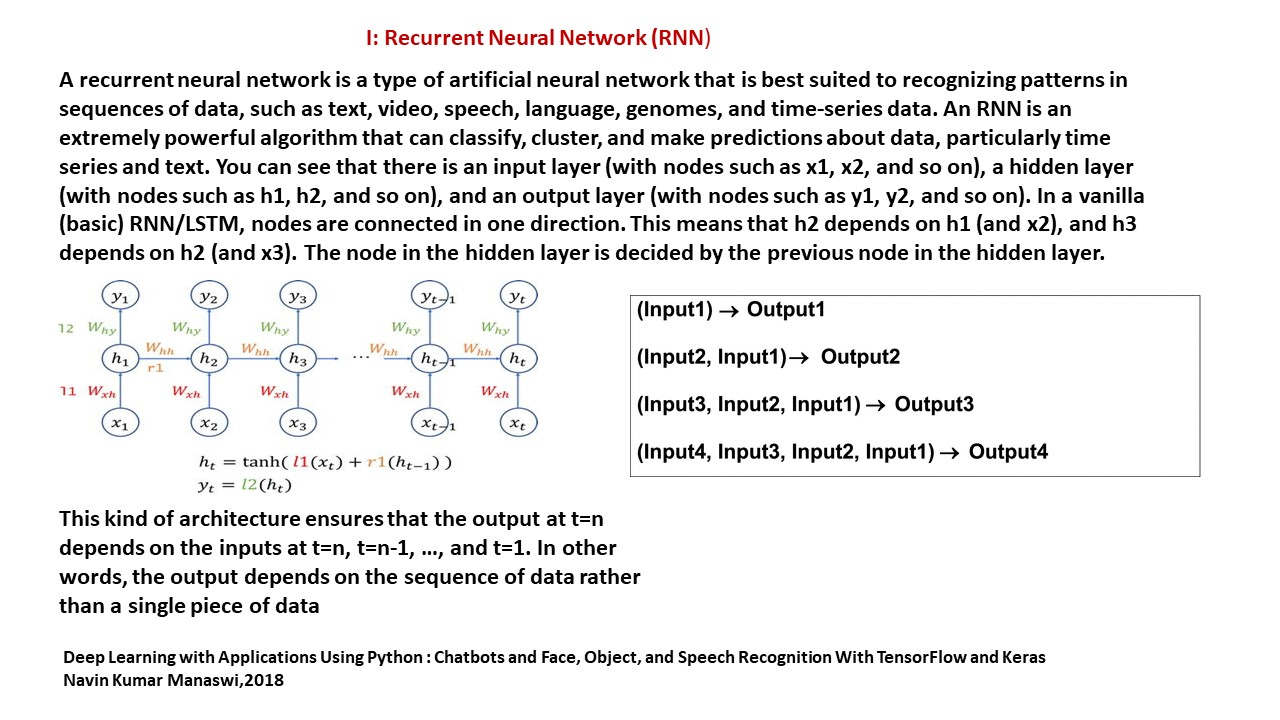

In [ ]:
display(Image(filename='/content/drive/MyDrive/Slides/Project3/RNN_1.jpeg', width = 900))

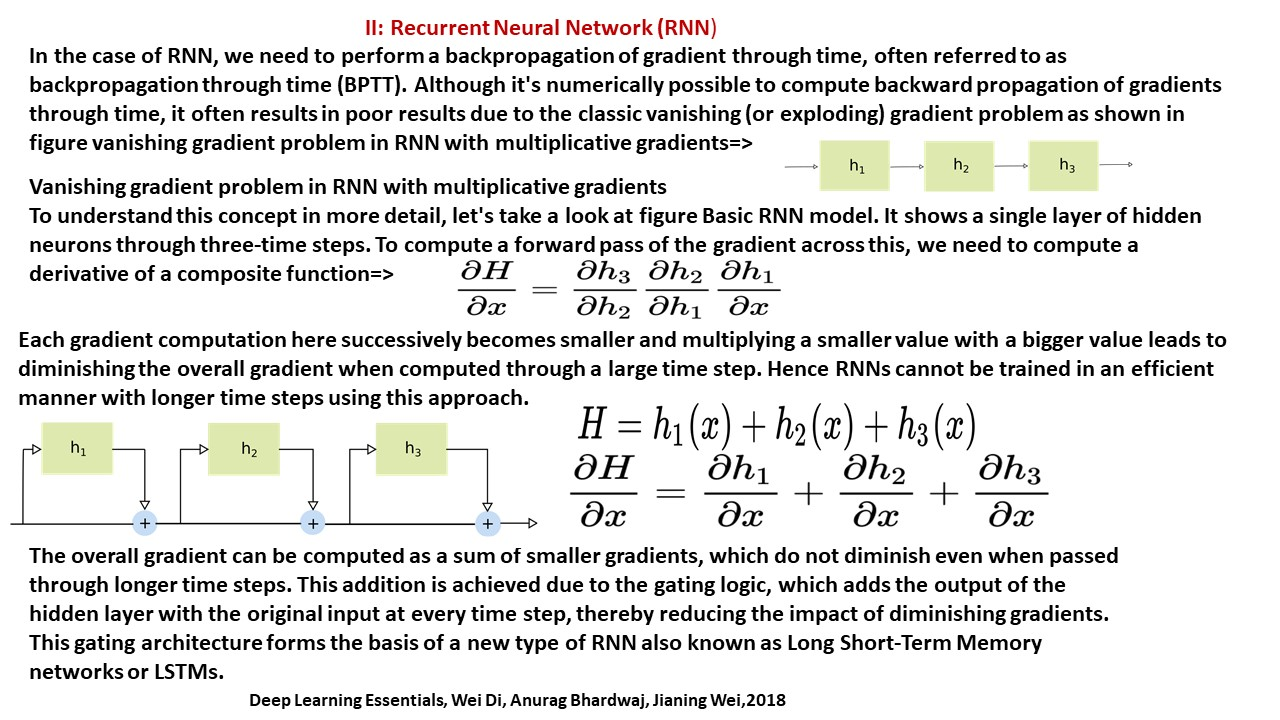

In [ ]:
display(Image(filename='/content/drive/MyDrive/Slides/Project3/RNN_2.jpeg', width = 900))

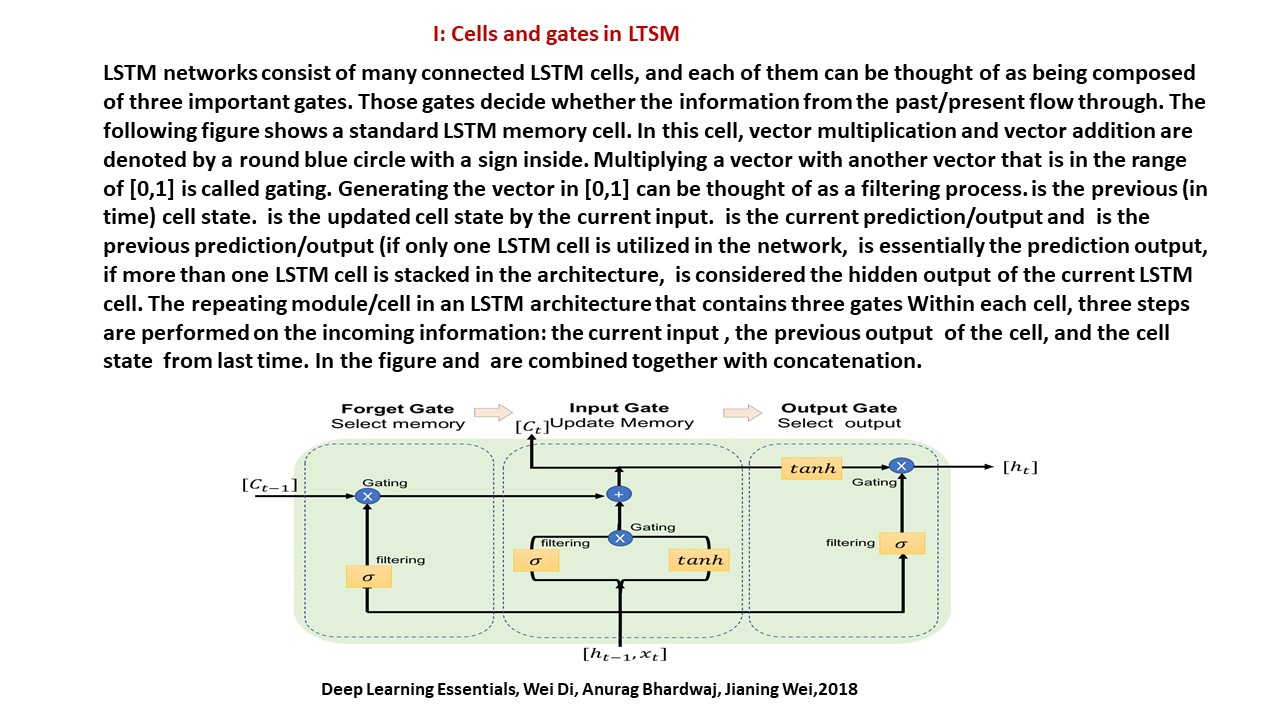

In [ ]:
display(Image(filename='/content/drive/MyDrive/Slides/Project3/LSTM_1.jpeg', width = 900))

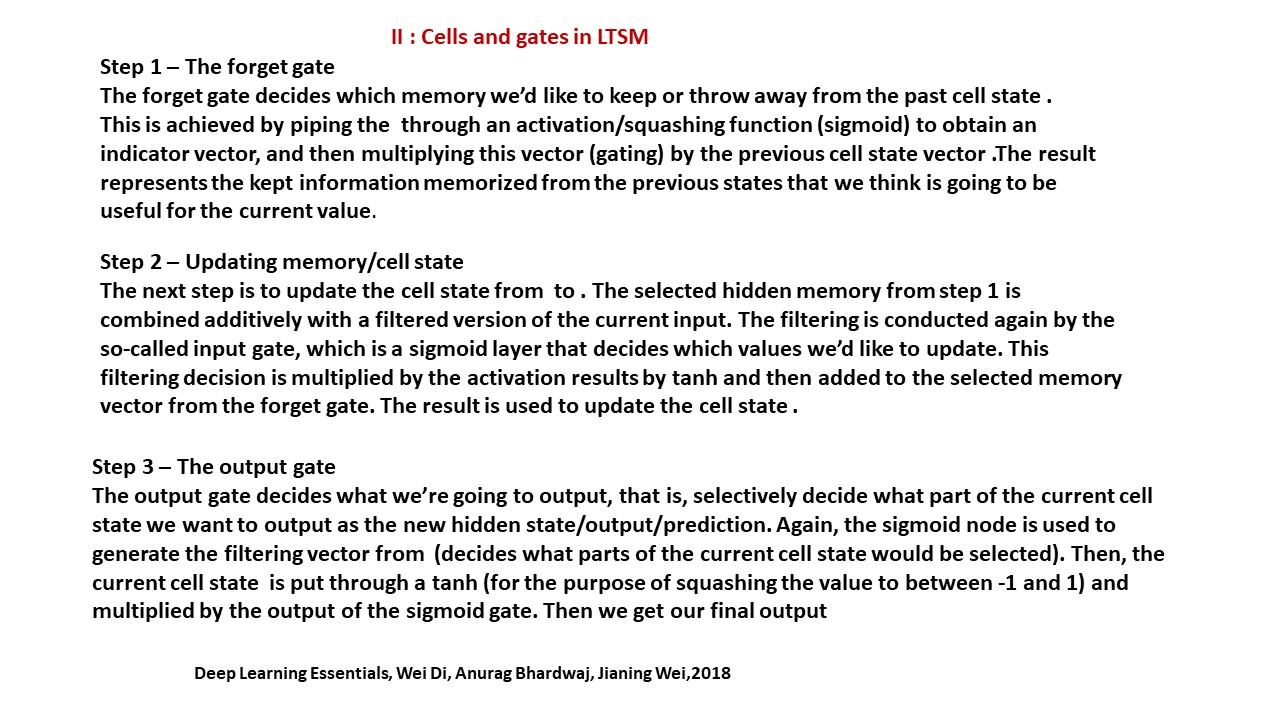

In [ ]:
display(Image(filename='/content/drive/MyDrive/Slides/Project3/LSTM_2.jpeg', width = 900))

### LSTM Equations

An LSTM cell has four main components: the forget gate, the input gate, the cell state update, and the output gate. Each of these components plays a crucial role in regulating the flow of information through the cell.

1. **Forget Gate**:
   The forget gate decides what information from the previous cell state $C_{t-1}$ should be discarded. It outputs a value between 0 and 1 for each number in the cell state $C_{t-1}$.

   $$f_t = \sigma(W_f h_{t-1} + U_f x_t + b_f)$$
   

   Here:
   - $\sigma$ is the sigmoid function.
   - $W_f$ is the weight matrix for the hidden state $h_{t-1}$.
   - $U_f$ is the weight matrix for the input $x_t$.
   - $b_f$ is the bias vector for the forget gate.
   - $h_{t-1}$ is the hidden state from the previous time step.
   - $x_t$ is the input at the current time step $t$.

2. **Input Gate**:
   The input gate determines which new information should be added to the cell state. It has two parts: the gate layer that decides which values to update and the $\tanh$ layer that creates new candidate values.

   $$i_t = \sigma(W_i h_{t-1} + U_i x_t + b_i)$$
   
   $$\tilde{C}_t = \tanh(W_C h_{t-1} + U_C x_t + b_C)$$
   

   Here:
   - $i_t$ is the input gate vector.
   - $W_i$, $U_i$, $b_i$ are the weights and biases for the input gate.
   - $\tilde{C}_t$ is the candidate cell state.
   - $\tanh$ is the hyperbolic tangent function.
   - $W_C$, $U_C$, $b_C$ are the weights and biases for the candidate cell state.

3. **Cell State Update**:
   The new cell state $C_t$ is a combination of the old cell state $C_{t-1}$ and the new candidate cell state $\tilde{C}_t$, modulated by the forget gate $f_t$ and the input gate $i_t$.

   $$C_t = f_t \ast C_{t-1} + i_t \ast \tilde{C}_t$$
   

   Here:
   - $C_t$ is the updated cell state.
   - $\ast$ denotes element-wise multiplication.

4. **Output Gate**:
   The output gate determines what part of the cell state should be output as the hidden state $h_t$. This is modulated by the output gate and a $\tanh$ function applied to the cell state.

   $$o_t = \sigma(W_o h_{t-1} + U_o x_t + b_o)$$
   
   $$h_t = o_t \ast \tanh(C_t)$$
   

   Here:
   - $o_t$ is the output gate vector.
   - $W_o$, $U_o$, $b_o$ are the weights and biases for the output gate.
   - $h_t$ is the hidden state for the current time step.

### Summary of Gates and States

- **Forget Gate $f_t$**: Decides what to discard from the previous cell state $C_{t-1}$.
- **Input Gate $i_t$**: Decides which values to update in the cell state.
- **Candidate Cell State $\tilde{C}_t$**: New candidate values for the cell state.
- **Cell State $C_t$**: Updated cell state, combining old state and new candidate values.
- **Output Gate $o_t$**: Decides what part of the cell state to output as the hidden state.
- **Hidden State $h_t$**: The output of the LSTM cell, used for predictions and passed to the next time step.

Each gate uses a set of weights and biases that are learned during the training process to optimize the LSTM's performance on sequential data tasks. The sigmoid and $\tanh$ functions ensure that the values are kept within appropriate ranges, providing stability and helping to regulate the flow of information.

### Example Sequence

Let's consider a sequence of three inputs: $x = [1, 0, 1]$.

### Initial Conditions

- Initial hidden state $h_0 = 0$
- Initial cell state $C_0 = 0$

### Weights and Biases

Let's assume the following weights and biases:

- **Forget Gate**:

  $$W_f = \begin{bmatrix} 0.5 & 0.3 \\ 0.1 & 0.7 \end{bmatrix}, \quad U_f = \begin{bmatrix} 0.4 \\ 0.8 \end{bmatrix}, \quad b_f = \begin{bmatrix} -0.1 \\ 0.2 \end{bmatrix}$$

- **Input Gate**:

  $$W_i = \begin{bmatrix} 0.2 & 0.6 \\ 0.5 & 0.9 \end{bmatrix}, \quad U_i = \begin{bmatrix} 0.7 \\ 0.3 \end{bmatrix}, \quad b_i = \begin{bmatrix} 0.1 \\ -0.2 \end{bmatrix}$$

  $$W_C = \begin{bmatrix} 0.8 & 0.2 \\ 0.6 & 0.4 \end{bmatrix}, \quad U_C = \begin{bmatrix} 0.5 \\ 0.7 \end{bmatrix}, \quad b_C = \begin{bmatrix} 0.0 \\ 0.1 \end{bmatrix}$$

- **Output Gate**:

  $$W_o = \begin{bmatrix} 0.3 & 0.4 \\ 0.2 & 0.6 \end{bmatrix}, \quad U_o = \begin{bmatrix} 0.9 \\ 0.5 \end{bmatrix}, \quad b_o = \begin{bmatrix} 0.05 \\ -0.05 \end{bmatrix}$$

### Forward Pass

Let's perform the forward pass for each time step.

**At $t=1$ (Input $x_1 = 1$)**:

- Concatenate $h_0$ and $x_1$:
  $[h_0, x_1] = [0, 1]$

1. **Forget Gate**:

   $ f_1 = \sigma(W_f h_0 + U_f x_1 + b_f) = \sigma\left(\begin{bmatrix} 0.5 & 0.3 \\ 0.1 & 0.7 \end{bmatrix} \cdot \begin{bmatrix} 0 \\ 1 \end{bmatrix} + \begin{bmatrix} 0.4 \\ 0.8 \end{bmatrix} \cdot 1 + \begin{bmatrix} -0.1 \\ 0.2 \end{bmatrix}\right)$

   $ = \sigma\left(\begin{bmatrix} 0.3 + 0.4 - 0.1 \\ 0.7 + 0.8 + 0.2 \end{bmatrix}\right) = \sigma\left(\begin{bmatrix} 0.6 \\ 1.7 \end{bmatrix}\right) = \begin{bmatrix} 0.6457 \\ 0.8455 \end{bmatrix}$


2. **Input Gate**:

   $ i_1 = \sigma(W_i h_0 + U_i x_1 + b_i) = \sigma\left(\begin{bmatrix} 0.2 & 0.6 \\ 0.5 & 0.9 \end{bmatrix} \cdot \begin{bmatrix} 0 \\ 1 \end{bmatrix} + \begin{bmatrix} 0.7 \\ 0.3 \end{bmatrix} \cdot 1 + \begin{bmatrix} 0.1 \\ -0.2 \end{bmatrix}\right)$

   $ = \sigma\left(\begin{bmatrix} 0.6 + 0.7 + 0.1 \\ 0.9 + 0.3 - 0.2 \end{bmatrix}\right) = \sigma\left(\begin{bmatrix} 1.4 \\ 1.0 \end{bmatrix}\right) = \begin{bmatrix} 0.8022 \\ 0.7311 \end{bmatrix}$

   $ \tilde{C}_1 = \tanh(W_C h_0 + U_C x_1 + b_C) = \tanh\left(\begin{bmatrix} 0.8 & 0.2 \\ 0.6 & 0.4 \end{bmatrix} \cdot \begin{bmatrix} 0 \\ 1 \end{bmatrix} + \begin{bmatrix} 0.5 \\ 0.7 \end{bmatrix} \cdot 1 + \begin{bmatrix} 0.0 \\ 0.1 \end{bmatrix}\right)$

   $ = \tanh\left(\begin{bmatrix} 0.2 + 0.5 + 0.0 \\ 0.4 + 0.7 + 0.1 \end{bmatrix}\right) = \tanh\left(\begin{bmatrix} 0.7 \\ 1.2 \end{bmatrix}\right) = \begin{bmatrix} 0.6044 \\ 0.8337 \end{bmatrix}$


3. **Cell State Update**:

   $ C_1 = f_1 \ast C_0 + i_1 \ast \tilde{C}_1 = \begin{bmatrix} 0.6457 \\ 0.8455 \end{bmatrix} \ast \begin{bmatrix} 0 \\ 0 \end{bmatrix} + \begin{bmatrix} 0.8022 \\ 0.7311 \end{bmatrix} \ast \begin{bmatrix} 0.6044 \\ 0.8337 \end{bmatrix}$

   $ = \begin{bmatrix} 0.0 \\ 0.0 \end{bmatrix} + \begin{bmatrix} 0.485 \\ 0.609 \end{bmatrix} = \begin{bmatrix} 0.485 \\ 0.609 \end{bmatrix}$


4. **Output Gate**:

   $ o_1 = \sigma(W_o h_0 + U_o x_1 + b_o) = \sigma\left(\begin{bmatrix} 0.3 & 0.4 \\ 0.2 & 0.6 \end{bmatrix} \cdot \begin{bmatrix} 0 \\ 1 \end{bmatrix} + \begin{bmatrix} 0.9 \\ 0.5 \end{bmatrix} \cdot 1 + \begin{bmatrix} 0.05 \\ -0.05 \end{bmatrix}\right)$

   $ = \sigma\left(\begin{bmatrix} 0.4 + 0.9 + 0.05 \\ 0.6 + 0.5 - 0.05 \end{bmatrix}\right) = \sigma\left(\begin{bmatrix} 1.35 \\ 1.05 \end{bmatrix}\right) = \begin{bmatrix} 0.794 \\ 0.741 \end{bmatrix}$

   $ h_1 = o_1 \ast \tanh(C_1) = \begin{bmatrix} 0.794 \\ 0.741 \end{bmatrix} \ast \tanh\left(\begin{bmatrix} 0.485 \\ 0.609 \end{bmatrix}\right) = \begin{bmatrix} 0.794 \\ 0.741 \end{bmatrix} \ast \begin{bmatrix} 0.450 \\ 0.543 \end{bmatrix}$

   $ = \begin{bmatrix} 0.357 \\ 0.402 \end{bmatrix}$


This completes the forward pass for the first time step. The process is repeated similarly for the subsequent time steps, using the updated hidden state $h_t$ and cell state $C_t$ as inputs for the next time step.

**At $t=2$ (Input $x_2 = 0$)**:

- Concatenate $h_1$ and $x_2$:
  $[h_1, x_2] = [0.357, 0.402, 0]$

1. **Forget Gate**:

   $f_2 = \sigma(W_f h_1 + U_f x_2 + b_f) = \sigma\left(\begin{bmatrix} 0.5 & 0.3 \\ 0.1 & 0.7 \end{bmatrix} \cdot \begin{bmatrix} 0.357 \\ 0.402 \end{bmatrix} + \begin{bmatrix} 0.4 \\ 0.8 \end{bmatrix} \cdot 0 + \begin{bmatrix} -0.1 \\ 0.2 \end{bmatrix}\right)$

   $ = \sigma\left(\begin{bmatrix} 0.1785 + 0.1206 - 0.1 \\ 0.0357 + 0.2814 + 0.2 \end{bmatrix}\right) = \sigma\left(\begin{bmatrix} 0.1991 \\ 0.5171 \end{bmatrix}\right) = \begin{bmatrix} 0.5496 \\ 0.6265 \end{bmatrix}$


2. **Input Gate**:

   $ i_2 = \sigma(W_i h_1 + U_i x_2 + b_i) = \sigma\left(\begin{bmatrix} 0.2 & 0.6 \\ 0.5 & 0.9 \end{bmatrix} \cdot \begin{bmatrix} 0.357 \\ 0.402 \end{bmatrix} + \begin{bmatrix} 0.7 \\ 0.3 \end{bmatrix} \cdot 0 + \begin{bmatrix} 0.1 \\ -0.2 \end{bmatrix}\right)$

   $ = \sigma\left(\begin{bmatrix} 0.0714 + 0.2412 + 0.1 \\ 0.1785 + 0.3618 - 0.2 \end{bmatrix}\right) = \sigma\left(\begin{bmatrix} 0.4126 \\ 0.3403 \end{bmatrix}\right) = \begin{bmatrix} 0.6017 \\ 0.5842 \end{bmatrix}$

   $ \tilde{C}_2 = \tanh(W_C h_1 + U_C x_2 + b_C) = \tanh\left(\begin{bmatrix} 0.8 & 0.2 \\ 0.6 & 0.4 \end{bmatrix} \cdot \begin{bmatrix} 0.357 \\ 0.402 \end{bmatrix} + \begin{bmatrix} 0.5 \\ 0.7 \end{bmatrix} \cdot 0 + \begin{bmatrix} 0.0 \\ 0.1 \end{bmatrix}\right)$

   $ = \tanh\left(\begin{bmatrix} 0.2856 + 0.0804 + 0.0 \\ 0.2142 + 0.1608 + 0.1 \end{bmatrix}\right) = \tanh\left(\begin{bmatrix} 0.366 \\ 0.475 \end{bmatrix}\right) = \begin{bmatrix} 0.3501 \\ 0.4429 \end{bmatrix}$


3. **Cell State Update**:

   $ C_2 = f_2 \ast C_1 + i_2 \ast \tilde{C}_2 = \begin{bmatrix} 0.5496 \\ 0.6265 \end{bmatrix} \ast \begin{bmatrix} 0.485 \\ 0.609 \end{bmatrix} + \begin{bmatrix} 0.6017 \\ 0.5842 \end{bmatrix} \ast \begin{bmatrix} 0.3501 \\ 0.4429 \end{bmatrix}$

   $ = \begin{bmatrix} 0.2664 \\ 0.3817 \end{bmatrix} + \begin{bmatrix} 0.2104 \\ 0.2586 \end{bmatrix} = \begin{bmatrix} 0.4768 \\ 0.6403 \end{bmatrix}$


4. **Output Gate**:

   $ o_2 = \sigma(W_o h_1 + U_o x_2 + b_o) = \sigma\left(\begin{bmatrix} 0.3 & 0.4 \\ 0.2 & 0.6 \end{bmatrix} \cdot \begin{bmatrix} 0.357 \\ 0.402 \end{bmatrix} + \begin{bmatrix} 0.9 \\ 0.5 \end{bmatrix} \cdot 0 + \begin{bmatrix} 0.05 \\ -0.05 \end{bmatrix}\right)$

   $ = \sigma\left(\begin{bmatrix} 0.1071 + 0.1608 + 0.05 \\ 0.0714 + 0.2412 - 0.05 \end{bmatrix}\right) = \sigma\left(\begin{bmatrix} 0.3179 \\ 0.2626 \end{bmatrix}\right) = \begin{bmatrix} 0.5788 \\ 0.5653 \end{bmatrix}$

   $ h_2 = o_2 \ast \tanh(C_2) = \begin{bmatrix} 0.5788 \\ 0.5653 \end{bmatrix} \ast \tanh\left(\begin{bmatrix} 0.4768 \\ 0.6403 \end{bmatrix}\right) = \begin{bmatrix} 0.5788 \\ 0.5653 \end{bmatrix} \ast \begin{bmatrix} 0.4439 \\ 0.5642 \end{bmatrix}$

   $ = \begin{bmatrix} 0.2571 \\ 0.3190 \end{bmatrix}$


**At $t=3$ (Input $x_3 = 1$)**:

- Concatenate $h_2$ and $x_3$:
  $[h_2, x_3] = [0.2571, 0.3190, 1]$

1. **Forget Gate**:

   $ f_3 = \sigma(W_f h_2 + U_f x_3 + b_f) = \sigma\left(\begin{bmatrix} 0.5 & 0.3 \\ 0.1 & 0.7 \end{bmatrix} \cdot \begin{bmatrix} 0.2571 \\ 0.3190 \end{bmatrix} + \begin{bmatrix} 0.4 \\ 0.8 \end{bmatrix} \cdot 1 + \begin{bmatrix} -0.1 \\ 0.2 \end{bmatrix}\right)$

   $ = \sigma\left(\begin{bmatrix} 0.1286 + 0.0957 + 0.4 - 0.1 \\ 0.0257 + 0.2233 + 0.8 + 0.2 \end{bmatrix}\right) = \sigma\left(\begin{bmatrix} 0.5243 \\ 1.249 \end{bmatrix}\right) = \begin{bmatrix} 0.6282 \\ 0.7771 \end{bmatrix}$


2. **Input Gate**:

   $ i_3 = \sigma(W_i h_2 + U_i x_3 + b_i) = \sigma\left(\begin{bmatrix} 0.2 & 0.6 \\ 0.5 & 0.9 \end{bmatrix} \cdot \begin{bmatrix} 0.2571 \\ 0.3190 \end{bmatrix} + \begin{bmatrix} 0.7 \\ 0.3 \end{bmatrix} \cdot 1 + \begin{bmatrix} 0.1 \\ -0.2 \end{bmatrix}\right)$

   $ = \sigma\left(\begin{bmatrix} 0.0514 + 0.1914 + 0.7 + 0.1 \\ 0.1286 + 0.2871 + 0.3 - 0.2 \end{bmatrix}\right) = \sigma\left(\begin{bmatrix} 1.043 \\ 0.5157 \end{bmatrix}\right) = \begin{bmatrix} 0.7394 \\ 0.6261 \end{bmatrix}$

   $\tilde{C}_3 = \tanh(W_C h_2 + U_C x_3 + b_C) = \tanh\left(\begin{bmatrix} 0.8 & 0.2 \\ 0.6 & 0.4 \end{bmatrix} \cdot \begin{bmatrix} 0.2571 \\ 0.3190 \end{bmatrix} + \begin{bmatrix} 0.5 \\ 0.7 \end{bmatrix} \cdot 1 + \begin{bmatrix} 0.0 \\ 0.1 \end{bmatrix}\right)$

   $ = \tanh\left(\begin{bmatrix} 0.2057 + 0.0638 + 0.5 + 0.0 \\ 0.1543 + 0.1276 + 0.7 + 0.1 \end{bmatrix}\right) = \tanh\left(\begin{bmatrix} 0.7695 \\ 1.082 \end{bmatrix}\right) = \begin{bmatrix} 0.6465 \\ 0.7931 \end{bmatrix}$


3. **Cell State Update**:

   $ C_3 = f_3 \ast C_2 + i_3 \ast \tilde{C}_3 = \begin{bmatrix} 0.6282 \\ 0.7771 \end{bmatrix} \ast \begin{bmatrix} 0.4768 \\ 0.6403 \end{bmatrix} + \begin{bmatrix} 0.7394 \\ 0.6261 \end{bmatrix} \ast \begin{bmatrix} 0.6465 \\ 0.7931 \end{bmatrix}$

   $ = \begin{bmatrix} 0.2995 \\ 0.4976 \end{bmatrix} + \begin{bmatrix} 0.477 \\ 0.4967 \end{bmatrix} = \begin{bmatrix} 0.7765 \\ 0.9943 \end{bmatrix}$


4. **Output Gate**:

   $ o_3 = \sigma(W_o h_2 + U_o x_3 + b_o) = \sigma\left(\begin{bmatrix} 0.3 & 0.4 \\ 0.2 & 0.6 \end{bmatrix} \cdot \begin{bmatrix} 0.2571 \\ 0.3190 \end{bmatrix} + \begin{bmatrix} 0.9 \\ 0.5 \end{bmatrix} \cdot 1 + \begin{bmatrix} 0.05 \\ -0.05 \end{bmatrix}\right)$

   $ = \sigma\left(\begin{bmatrix} 0.0771 + 0.1276 + 0.9 + 0.05 \\ 0.0514 + 0.1914 + 0.5 - 0.05 \end{bmatrix}\right) = \sigma\left(\begin{bmatrix} 1.1547 \\ 0.6928 \end{bmatrix}\right) = \begin{bmatrix} 0.7603 \\ 0.6666 \end{bmatrix}$

   $ h_3 = o_3 \ast \tanh(C_3) = \begin{bmatrix} 0.7603 \\ 0.6666 \end{bmatrix} \ast \tanh\left(\begin{bmatrix} 0.7765 \\ 0.9943 \end{bmatrix}\right) = \begin{bmatrix} 0.7603 \\ 0.6666 \end{bmatrix} \ast \begin{bmatrix} 0.6511 \\ 0.7592 \end{bmatrix}$

   $ = \begin{bmatrix} 0.4949 \\ 0.5060 \end{bmatrix}$


This completes the forward pass for the sequence. The hidden states $h_t$ at each time step are as follows:

- $h_1 = \begin{bmatrix} 0.357 \\ 0.402 \end{bmatrix}$
- $h_2 = \begin{bmatrix} 0.2571 \\ 0.3190 \end{bmatrix}$
- $h_3 = \begin{bmatrix} 0.4949 \\ 0.5060 \end{bmatrix}$

### Backpropagation Through Time (BPTT) for LSTM

To train an LSTM, we need to compute gradients and update weights using backpropagation through time (BPTT). The process involves computing gradients for each gate and cell state, and then propagating these gradients backward through the sequence.

**At $t=3$**:
Let's denote the loss function as $L$. For simplicity, let's focus on the gradients for the last time step $t=3$.

1. **Gradient of Loss with Respect to Output Gate**:
   $$ \frac{\partial L}{\partial o_3} = \frac{\partial L}{\partial h_3} \ast \tanh(C_3)$$

   $$ \frac{\partial L}{\partial W_o} = \frac{\partial L}{\partial o_3} \cdot \frac{\partial o_3}{\partial W_o}$$


2. **Gradient of Loss with Respect to Cell State**:
   $$ \frac{\partial L}{\partial C_3} = \frac{\partial L}{\partial h_3} \ast o_3 \ast (1 - \tanh^2(C_3)) + \frac{\partial L}{\partial C_{t+1}} \ast f_{t+1}$$


3. **Gradient of Loss with Respect to Forget Gate**:
   $$ \frac{\partial L}{\partial f_3} = \frac{\partial L}{\partial C_3} \ast C_2$$

   $$ \frac{\partial L}{\partial W_f} = \frac{\partial L}{\partial f_3} \cdot \frac{\partial f_3}{\partial W_f}$$


4. **Gradient of Loss with Respect to Input Gate**:
   $$ \frac{\partial L}{\partial i_3} = \frac{\partial L}{\partial C_3} \ast \tilde{C}_3$$

   $$ \frac{\partial L}{\partial W_i} = \frac{\partial L}{\partial i_3} \cdot \frac{\partial i_3}{\partial W_i}$$


5. **Gradient of Loss with Respect to Candidate Cell State**:
   $$ \frac{\partial L}{\partial \tilde{C}_3} = \frac{\partial L}{\partial C_3} \ast i_3$$

   $$ \frac{\partial L}{\partial W_C} = \frac{\partial L}{\partial \tilde{C}_3} \cdot \frac{\partial \tilde{C}_3}{\partial W_C}$$


# B)

#**Part I**
#**In this part, we will be using the example data from the Max Planck Institute for Biogeochemistry. The dataset is called the Jena Climate dataset. It contains measurements like temperature, humidity, and more, recorded every 10 minutes. You have a dataset with measures on weather data, and we try to predict the temperature 12 hours (72-time steps of 10 minutes) into the future.We will use only the temperature data and not the other variables. This may make the task slightly harder to accomplish. Note that it is possible to add other explanatory variables into an RNN. For forecasting tomorrow’s temperature, you may want to use not only today’s temperature but also today’s wind direction, wind speed, and humidity, for example. In this case, you could add a third dimension to the input data.**

#**Reference : Advanced Forecasting with Python: With State-of-the-Art-Models Including LSTMs, Facebook’s Prophet, and Amazon’s DeepAR, Joos Korstanje, 2021**

#**1.Import libraries**

In [ ]:
import keras
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

#**2.Import our data.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from IPython.display import Image

In [ ]:
csv_path = "/content/drive/MyDrive/Dataset/jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)

df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


#**3. The next step is to delete all columns other than the temperature, as we are building a univariate model. Keeping only the temperature data.**

In [ ]:
df = df[['T (degC)']]

df

,T (degC)
0,-8.02
1,-8.41
2,-8.51
3,-8.31
4,-8.27
...,...
420546,-4.05
420547,-3.35
420548,-3.16
420549,-4.23


#**4. We apply the min-max scaler.**

In [ ]:
scaler = MinMaxScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns = ['T'])

df

,T
0,0.248632
1,0.242163
2,0.240504
3,0.243822
4,0.244485
...,...
420546,0.314480
420547,0.326091
420548,0.329242
420549,0.311494


# **5. We prepare our data and convert the list of lists to numpy array.We need to split the data into a shape in which we have sequences of past data and sequences of future data. We want to predict 72 steps into the future, and we’ll use 3*72 steps into the past. This is an arbitrary choice. You can try out using more or less past data.**

In [ ]:
# Convert the 'T' column of the DataFrame to a list
ylist = list(df['T'])
ylist

[0.2486316138663128,
 0.24216287941615522,
 0.24050422955714046,
 0.24382152927516998,
 0.2444849892187759,
 0.24813401890860837,
 0.25526621330237187,
 0.25526621330237187,
 0.250456128711229,
 0.24183114944435227,
 0.23635760490960356,
 0.23436722507878582,
 0.23486482003649028,
 0.23519655000829323,
 0.23801625476861832,
 0.23801625476861832,
 0.23735279482501243,
 0.23552827998009618,
 0.23503068502239174,
 0.23337203516337698,
 0.23337203516337698,
 0.2346989550505888,
 0.2325427102338696,
 0.23154752031846074,
 0.22856195057223416,
 0.2242494609387958,
 0.22408359595289432,
 0.22657157074141648,
 0.22458119091059875,
 0.22192735113617512,
 0.22126389119256923,
 0.22109802620666777,
 0.21744899651683527,
 0.2172831315309338,
 0.22391773096699286,
 0.22126389119256923,
 0.22259081107978104,
 0.22988887045944598,
 0.23386963012108142,
 0.23171338530436225,
 0.22524465085420467,
 0.22955714048764303,
 0.23718692983911094,
 0.23984076961353454,
 0.2423287444020567,
 0.2439873942610714

In [ ]:
# Define the number of future time steps to predict
n_future = 72

# Define the number of past time steps to use as input
n_past = 4 * 72 # I used more past data rather than the initial value which was 3 * 72

# Define the total period which includes both past and future time steps
total_period = 5 * 72

# Initialize the end index to the length of the ylist
idx_end = len(ylist)

# Initialize the start index to capture the last 'total_period' time steps
idx_start = idx_end - total_period

# Initialize empty lists to hold the input (X_new) and output (y_new) sequences
X_new = []
y_new = []

# Loop until the start index goes below 0
while idx_start > 0:
    # Extract a sequence of past time steps (length n_past) for the current start index
    x_line = ylist[idx_start:idx_start + n_past]

    # Extract a sequence of future time steps (length n_future) for the current start index
    y_line = ylist[idx_start + n_past:idx_start + total_period]

    # Append the extracted sequences to the input and output lists
    X_new.append(x_line)
    y_new.append(y_line)

    # Move the start index one step back to create overlapping sequences
    idx_start = idx_start - 1

print(X_new)
print(y_new)

In [ ]:
# Convert the input and output lists to numpy arrays
X_new = np.array(X_new)
y_new = np.array(y_new)

print(X_new)
print(y_new)

#**6.We do train test split.**

In [ ]:
X_new.shape

In [ ]:
# It's usually better to use 20% for test rather than 10%
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.20, random_state=42)

In [ ]:
X_train.shape

In [ ]:
X_test.shape

#**7.It takes a long time to run this model. The batch size of 2000 is provided for demonstration purposes. But you need to put a much smaller batch size. Note that The SimpleRNN layer needs an input format that is 3D, and the shape has to correspond to (n_samples, n_timesteps, n_features). This can be obtained using reshape.**

In [ ]:
batch_size = 32 # I used smaller batch size rather than batch_size = 2000

# Determine the number of samples in the training data
n_samples = X_train.shape[0]

# Determine the number of timesteps in each training sample
n_timesteps = X_train.shape[1]

# Determine the number of steps in the training labels
n_steps = y_train.shape[1]

# Set the number of features for each timestep (1 in this case, assuming univariate time series)
n_features = 1

# Reshape the training data to match the required input shape for the model
# The new shape is (number of samples, number of timesteps, number of features)
X_train_rs = X_train.reshape(n_samples, n_timesteps, n_features)

# Reshape the test data to match the required input shape for the model
# The new shape is (number of test samples, number of timesteps, number of features)
X_test_rs = X_test.reshape(X_test.shape[0], n_timesteps, n_features)


#**8.We parameterize a small network with SimpleRNN.**
Line 1: -------
Line 2: -------
Line 3:-------

In [ ]:
random.seed(42)

simple_model = Sequential([
  # I used 64 units per layer instead of 8 units and it gets better
  SimpleRNN(64, activation='tanh',input_shape=(n_timesteps, n_features), return_sequences=True),
  SimpleRNN(64, activation='tanh', return_sequences = True),
  SimpleRNN(64, activation='tanh'),
  Dense(y_train.shape[1]),
])

simple_model.summary()

simple_model.compile(
  # I used lr = .001 instead of lr = .01
  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
  loss='mean_absolute_error',
  metrics=['mean_absolute_error'],
)

smod_history = simple_model.fit(X_train_rs, y_train,
          validation_split=0.2,
          epochs=5, # we could increase the number of epochs to get better results
          batch_size=batch_size,
          shuffle = True
)

preds = simple_model.predict(X_test_rs)



plt.plot(smod_history.history['loss'])
plt.plot(smod_history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
print(r2_score(preds, y_test))

In [ ]:
from IPython.display import Image
Image(filename='/content/drive/MyDrive/RNN-LSTM/RNN-NB-2.jpg', width=900,height=900)

#**9.A simple architecture with 1 Gated Recurrent Unit (GRU) layer.**

In [ ]:
random.seed(42)
from tensorflow.keras.layers import GRU

simple_model = Sequential([
    #I used 64 units instead of 8
   GRU(64, activation='tanh',input_shape=(n_timesteps, n_features)),
  Dense(y_train.shape[1]),
])

simple_model.summary()

simple_model.compile(
    # I used lr = 0.01 instead of lr = 0.1
  optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
  loss='mean_absolute_error',
  metrics=['mean_absolute_error'],
)

smod_history = simple_model.fit(X_train_rs, y_train,
          validation_split=0.2,
          epochs=5, # we could increase the number of epochs to get better results
          batch_size=batch_size,
          shuffle = True
)

preds = simple_model.predict(X_test_rs)



plt.plot(smod_history.history['loss'])
plt.plot(smod_history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
print(r2_score(preds, y_test))

#**10.This is a  more complex network with three layers of Gated Recurrent Unit (GRU).**

In [ ]:
random.seed(42)

simple_model = Sequential([
    # I used 128 units per layer instead of 10
    GRU(128, activation='tanh',input_shape=(n_timesteps, n_features), return_sequences=True),
    GRU(128, activation='tanh', return_sequences=True),
    GRU(128, activation='tanh'),
    Dense(y_train.shape[1]),
])

simple_model.summary()

simple_model.compile(
    # I used lr = .001 instead of lr = .01
  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
  loss='mean_absolute_error',
  metrics=['mean_absolute_error'],
)

smod_history = simple_model.fit(X_train_rs, y_train,
          validation_split=0.2,
          epochs=10, # we could increase the number of epochs to get better results
          batch_size=batch_size,
          shuffle = True
)

preds = simple_model.predict(X_test_rs)



plt.plot(smod_history.history['loss'])
plt.plot(smod_history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
print(r2_score(preds, y_test))

#**Part II**
#**In this part, we will employ LSTM.This section uses the stock market data(SP500).**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [14]:
from IPython.display import Image

#**1. Import libraries.**

In [15]:
import pandas
import matplotlib.pyplot as plt
import numpy
import matplotlib.pyplot as plt
import pandas
import math
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import numpy as np

# **2. We normalize the dataset and do train and test split.**

1. **Loading the Dataset**:
   - `dataset = pandas.read_csv("/content/drive/MyDrive/Dataset/sp500.csv", usecols=[0], engine='python', skipfooter=3)`: This line reads the CSV file located at the specified path (`/content/drive/MyDrive/Dataset/sp500.csv`). It uses the `pandas` library to load the data.
     - `usecols=[0]`: This argument specifies that only the first column (index 0) of the CSV file should be read.
     - `engine='python'`: This specifies the parsing engine to use. The Python engine is more flexible but slower compared to the default C engine.
     - `skipfooter=3`: This skips the last three lines in the file, which might contain footer information that's not part of the dataset.

2. **Plotting the Dataset**:
   - `plt.plot(dataset)`: This plots the data from the dataset using the `matplotlib` library.
   - `plt.show()`: This displays the plot.


3. **Scaling Data**:
   - `scaler = MinMaxScaler(feature_range=(0, 1))`: This creates an instance of the `MinMaxScaler` from `sklearn.preprocessing`, which will scale the dataset to the range [0, 1].
   - `dataset = scaler.fit_transform(dataset)`: This scales the dataset. The `fit_transform` method fits the scaler to the data and then transforms it, ensuring all values are between 0 and 1.

4. **Splitting Data into Training and Test Sets**:
   - `train_size = int(len(dataset) * 0.67)`: This calculates the size of the training set, which is 67% of the total dataset.
   - `test_size = len(dataset) - train_size`: This calculates the size of the test set, which is the remaining 33% of the dataset.
   - `train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]`: This splits the dataset into training and test sets.
     - `dataset[0:train_size,:]`: Selects the first `train_size` rows for the training set.
     - `dataset[train_size:len(dataset),:]`: Selects the remaining rows for the test set.

5. **Printing the Sizes of the Training and Test Sets**:
   - `print(len(train), len(test))`: This prints the number of samples in the training and test sets.


In [18]:
dataset = pandas.read_csv('/content/drive/MyDrive/Dataset/sp500.csv', usecols=[0], engine='python', skipfooter=3)
dataset

,1455.219971
count,4167.000000
mean,1355.135150
std,341.903406
min,676.530029
25%,1123.294983
50%,1285.500000
75%,1484.099976
max,2175.030029


In [11]:
plt.plot(dataset)
plt.show()

scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
print(len(train), len(test))

InvalidIndexError: (slice(0, 166, None), slice(None, None, None))

In [5]:
print(dataset)

[[0.48240909]
 [0.48420417]
 [0.48509838]
 ...
 [0.99562893]
 [0.99609603]
 [0.99436106]]


# **3. We convert an array of values into a timeseries data.**

In [6]:
def create_dataset(dataset, look_back=1):
    """
    Creates a dataset where each input contains 'look_back' number of time steps
    and the corresponding output is the next time step after the input sequence.

    Parameters:
    - dataset (numpy array): The input data as a 2D numpy array (time series data).
    - look_back (int): Number of previous time steps to use as input to predict the next time step.

    Returns:
    - dataX (numpy array): Array of input sequences, each of length 'look_back'.
    - dataY (numpy array): Array of output values corresponding to each input sequence in dataX.
    """

    dataX, dataY = [], []  # Initialize lists to store input sequences (dataX) and corresponding output values (dataY)

    # Iterate through the dataset to create sequences
    for i in range(len(dataset) - look_back - 1):
        # Extract a sequence of 'look_back' time steps as input
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)  # Append the input sequence to dataX

        # Append the next time step's value as the output (prediction target)
        dataY.append(dataset[i + look_back, 0])

    # Convert lists to numpy arrays for better performance in numerical operations
    return np.array(dataX), np.array(dataY)

In [7]:
# Number of previous/past time steps to use as input for predicting the next/future time step
look_back = 1

In [8]:
# Create training dataset with look_back time steps
trainX, trainY = create_dataset(train, look_back)
print(trainX)
print(trainY)

[[0.48240909]
 [0.48420417]
 [0.48509838]
 ...
 [0.42112775]
 [0.41875209]
 [0.42080077]]
[0.48420417 0.48509838 0.51047043 ... 0.41875209 0.42080077 0.42331663]


In [9]:
# Create test dataset with look_back time steps
testX, testY = create_dataset(test, look_back)
print(testX)
print(testY)

[[0.43245907]
 [0.42999665]
 [0.4306573 ]
 ...
 [0.99342002]
 [1.        ]
 [0.99562893]]
[0.42999665 0.4306573  0.43551551 ... 1.         0.99562893 0.99609603]


In [ ]:
trainX.shape

# **4. We reshape input to be [samples, time steps, features].**

In [10]:
# Reshape the training input data to be 3-dimensional for LSTM input
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))

# Reshape the test input data to be 3-dimensional for LSTM input
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

# **5.We create and fit the LSTM network.**

In [11]:
# Create a Sequential model (linear stack of layers)
model = Sequential()

# Add an LSTM layer with 4 memory units and input shape (1, look_back)
model.add(LSTM(4, input_shape=(1, look_back)))

# Add a Dense (fully connected) layer with 1 unit (output dimension)
model.add(Dense(1))

# Compile the model with mean squared error loss and Adam optimizer
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model on training data
# - epochs: Number of times to iterate over the entire training dataset
# - batch_size: Number of samples per gradient update
# - verbose: Verbosity mode (0: silent, 1: progress bar, 2: one line per epoch)
model.fit(trainX, trainY, epochs=100, batch_size=10, verbose=2)

Epoch 1/100
279/279 - 4s - loss: 0.0263 - 4s/epoch - 15ms/step
Epoch 2/100
279/279 - 1s - loss: 0.0051 - 603ms/epoch - 2ms/step
Epoch 3/100
279/279 - 1s - loss: 0.0030 - 589ms/epoch - 2ms/step
Epoch 4/100
279/279 - 1s - loss: 0.0012 - 633ms/epoch - 2ms/step
Epoch 5/100
279/279 - 1s - loss: 3.1870e-04 - 608ms/epoch - 2ms/step
Epoch 6/100
279/279 - 1s - loss: 1.3682e-04 - 621ms/epoch - 2ms/step
Epoch 7/100
279/279 - 1s - loss: 1.2328e-04 - 599ms/epoch - 2ms/step
Epoch 8/100
279/279 - 1s - loss: 1.2284e-04 - 611ms/epoch - 2ms/step
Epoch 9/100
279/279 - 1s - loss: 1.2146e-04 - 611ms/epoch - 2ms/step
Epoch 10/100
279/279 - 1s - loss: 1.2105e-04 - 605ms/epoch - 2ms/step
Epoch 11/100
279/279 - 1s - loss: 1.1942e-04 - 599ms/epoch - 2ms/step
Epoch 12/100
279/279 - 1s - loss: 1.1933e-04 - 588ms/epoch - 2ms/step
Epoch 13/100
279/279 - 1s - loss: 1.1853e-04 - 568ms/epoch - 2ms/step
Epoch 14/100
279/279 - 1s - loss: 1.1674e-04 - 608ms/epoch - 2ms/step
Epoch 15/100
279/279 - 1s - loss: 1.1541e-04 - 

#**6.We rescale predicted values and compute the root mean squared error.**

About inverse transform
1. Original Value: 10
2. Scaled Value: 0.1
3. Predicted Scaled Value: 0.2
4. Predicted Original Value after Inverse Transform: Approximately 20


In [12]:
# Predictions on training data
trainPredict = model.predict(trainX)

# Predictions on test data
testPredict = model.predict(testX)

# Inverse transform predictions to original scale using MinMaxScaler
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])  # Inverse transform training targets
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])  # Inverse transform test targets

# Calculate root mean squared error (RMSE) for training data
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))

# Calculate root mean squared error (RMSE) for test data
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

43/43 [==============================] - 0s 2ms/step
Train Score: 15.17 RMSE
Test Score: 55.46 RMSE


# **7. We shift train and test predictions for plotting and plot baseline and predictions.The part in orange is the training data, the part in blue is the test data, and the part in green is the predicted output.**

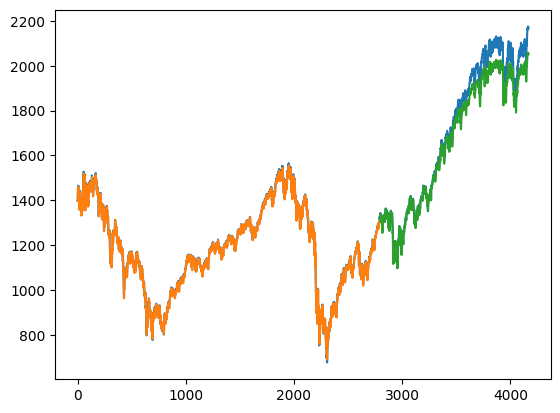

In [13]:
# Initialize empty arrays to store predicted values
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan  # Fill with NaNs to represent unknown values

# Place predicted values from training data into the plot array
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict

# Initialize empty arrays to store predicted values
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan  # Fill with NaNs to represent unknown values

# Place predicted values from test data into the plot array
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict

# Plot the original dataset in its original scale
plt.plot(scaler.inverse_transform(dataset))

# Plot the predicted values for training data
plt.plot(trainPredictPlot)

# Plot the predicted values for test data
plt.plot(testPredictPlot)

# Display the plot containing original data and predictions
plt.show()

#**References:**
#**[1] Advanced Forecasting with Python: With State-of-the-Art-Models Including LSTMs, Facebook’s Prophet, and Amazon’s DeepAR, Joos Korstanje, July 2021.**
#**[2]. Deep Learning: Recurrent Neural Networks with Python, AI Sciences, 2021.**
#**[3]. Deep Learning with Applications Using Python : Chatbots and Face, Object, and Speech Recognition With TensorFlow and Keras, Navin Kumar Manaswi, 2018.**
#**[4]. Machine Vision, GANs, and Deep Reinforcement Learning, Jon Krohn, 2020.**
#**[5]. Generating a New Reality: From Autoencoders and Adversarial Networks to Deepfakes, Micheal Lanham, 2021.**
#**[6].Hands-On Mathematics for Deep Learning, Jay Dawani, 2020**


# **part3**

# A)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from IPython.display import Image

### A* Algorithm Steps

1. **Initialize**:
   - Initialize an open list containing the starting node.
   - Initialize a closed list (or set) to keep track of nodes that have been evaluated.

2. **While Open List is Not Empty**:
   - Select the node with the lowest \( f \)-cost ( \( f = g + h \) ) from the open list. This node is the current node.
   - Move the current node to the closed list to mark it as evaluated.

3. **Goal Check**:
   - If the current node is the goal node, then a path has been found. Construct the path from the goal node to the start node using parent pointers and terminate.

4. **Generate Successor Nodes (Neighbors)**:
   - Generate all neighboring nodes (or successors) of the current node.
   - For each neighboring node:
     - Calculate \( g \)-value: Cost from the start node to the neighboring node through the current node.
     - Calculate \( h \)-value: Heuristic estimate of the cost from the neighboring node to the goal node.
     - Calculate \( f \)-value: Total estimated cost of the path through the neighboring node ( \( f = g + h \) ).

5. **Evaluate Neighbors**:
   - For each neighboring node:
     - If the neighboring node is already in the closed list and the new \( g \)-value is higher than its current \( g \)-value, skip it.
     - If the neighboring node is not in the open list or the new \( g \)-value is lower than its current \( g \)-value:
       - Update the \( g \)-value of the neighboring node.
       - Update the \( f \)-value of the neighboring node.
       - Set the parent of the neighboring node to the current node (for path reconstruction).
       - Add the neighboring node to the open list (if not already present).

6. **Repeat**:
   - Go back to step 2 and continue until either the goal node is reached (path found) or the open list is empty (no path exists).

7. **Termination**:
   - If the open list is empty and the goal node has not been reached, then no path exists from the start node to the goal node.

### Key Points
- **\( g \)-cost**: Represents the actual cost from the start node to the current node.
- **\( h \)-cost (Heuristic)**: Estimates the cost from the current node to the goal node. It guides the search towards the goal efficiently.
- **\( f \)-cost**: Combines \( g \) and \( h \) to estimate the total cost through the current node.

### Notes
- A* guarantees finding the shortest path if the heuristic is admissible (never overestimates) and consistent (satisfies the triangle inequality).
- The algorithm efficiently narrows down the search space by prioritizing nodes with lower \( f \)-costs, making it suitable for pathfinding in various applications.

This algorithmic approach helps in understanding how A* systematically explores and evaluates paths from a starting point to a goal, ensuring optimal pathfinding in graphs or grids.

## Example 1:

In [ ]:
def aStarAlgo(start_node, stop_node):

        open_set = set(start_node)
        closed_set = set()
        g = {} #store distance from starting node
        parents = {}# parents contains an adjacency map of all nodes

        #ditance of starting node from itself is zero
        g[start_node] = 0
        #start_node is root node i.e it has no parent nodes
        #so start_node is set to its own parent node
        parents[start_node] = start_node


        while len(open_set) > 0:
            n = None

            #node with lowest f() is found
            for v in open_set:
                if n == None or g[v] + heuristic(v) < g[n] + heuristic(n):
                    n = v


            if n == stop_node or Graph_nodes[n] == None:
                pass
            else:
                for (m, weight) in get_neighbors(n):
                    #nodes 'm' not in first and last set are added to first
                    #n is set its parent
                    if m not in open_set and m not in closed_set:
                        open_set.add(m)
                        parents[m] = n
                        g[m] = g[n] + weight


                    #for each node m,compare its distance from start i.e g(m) to the
                    #from start through n node
                    else:
                        if g[m] > g[n] + weight:
                            #update g(m)
                            g[m] = g[n] + weight
                            #change parent of m to n
                            parents[m] = n

                            #if m in closed set,remove and add to open
                            if m in closed_set:
                                closed_set.remove(m)
                                open_set.add(m)

            if n == None:
                print('Path does not exist!')
                return None

            # if the current node is the stop_node
            # then we begin reconstructin the path from it to the start_node
            if n == stop_node:
                path = []

                while parents[n] != n:
                    path.append(n)
                    n = parents[n]

                path.append(start_node)

                path.reverse()

                print('Path found: {}'.format(path))
                return path


            # remove n from the open_list, and add it to closed_list
            # because all of his neighbors were inspected
            open_set.remove(n)
            closed_set.add(n)

        print('Path does not exist!')
        return None

#define fuction to return neighbor and its distance
#from the passed node
def get_neighbors(v):
    if v in Graph_nodes:
        return Graph_nodes[v]
    else:
        return None

For example:
```
Graph_nodes = {
    'A': [('B', 1), ('C', 3)],
    'B': [('A', 1), ('D', 1), ('E', 5)],
    'C': [('A', 3), ('F', 2)],
    'D': [('B', 1), ('E', 1)],
    'E': [('B', 5), ('D', 1)],
    'F': [('C', 2)]
}
```

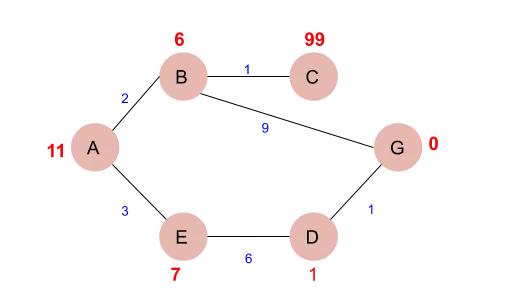

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/A_example_1_1.png', width = 600))

- g(x) + h(x) = f(x)
- 0+ 11 =11
- Thus for A, we can write
- A=11
- Now from A, we can go to point B or point E, so we compute f(x) for each of them
- A → B = 2 + 6 = 8
- A → E = 3 + 6 = 9

- Since the cost for  A → B is less, we move forward with this path and compute the f(x) for the children nodes of B
- Since there is no path between C and G, the heuristic cost is set to infinity or a very high value
- A → B → C = (2 + 1) + 99 = 102
- A → B → G = (2 + 9 ) + 0 = 11
- Here the path A → B → G has the least cost but it is still more than the cost of A → E, thus we explore this path further
- A → E → D = (3 + 6) + 1 = 10
- Comparing the cost of A → E → D with all the paths we got so far and as this cost is least of all we move forward with this path. And compute the f(x) for the children of D
- A → E → D → G = (3 + 6 + 1) +0 =10
- Now comparing all the paths that lead us to the goal, we conclude that A → E → D → G is the most cost-effective path to get from A to G.

In [ ]:
#for simplicity we ll consider heuristic distances given
#and this function returns heuristic distance for all nodes
def heuristic(n):
        H_dist = {
            'A': 11,
            'B': 6,
            'C': 99,
            'D': 1,
            'E': 7,
            'G': 0,

        }

        return H_dist[n]

#Describe your graph here
Graph_nodes = {
    'A': [('B', 2), ('E', 3)],
    'B': [('C', 1),('G', 9)],
    'C': None,
    'E': [('D', 6)],
    'D': [('G', 1)],

}
aStarAlgo('A', 'G')

Path found: ['A', 'E', 'D', 'G']


['A', 'E', 'D', 'G']

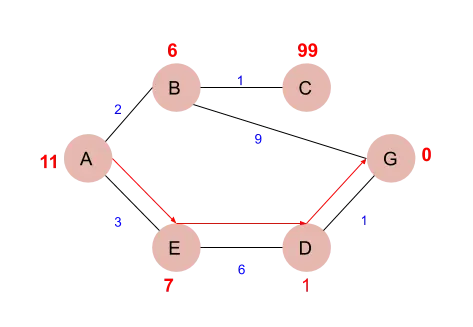

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/A_example_1_2.png', width = 600))

source: https://www.mygreatlearning.com/blog/a-search-algorithm-in-artificial-intelligence/

## Example 2

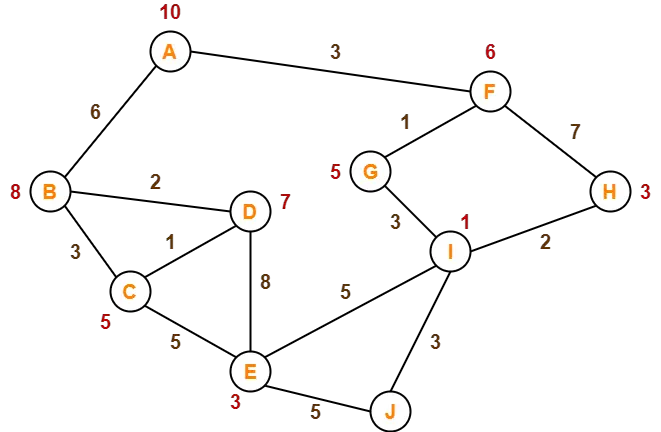

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/A_example_2_1.png', width = 600))

### Step-01:


- We start with node A.

- Node B and Node F can be reached from node A.


A* Algorithm calculates f(B) and f(F).

- $f(B) = 6 + 8 = 14$
- $f(F) = 3 + 6 = 9$


- Since f(F) < f(B), so it decides to go to node F.



- Path- A → F



### Step-02:


- Node G and Node H can be reached from node F.



- A* Algorithm calculates f(G) and f(H).

- $f(G) = (3+1) + 5 = 9$
- $f(H) = (3+7) + 3 = 13$


- Since f(G) < f(H), so it decides to go to node G.



- Path- A → F → G



### Step-03:


- Node I can be reached from node G.



- A* Algorithm calculates f(I).

- $f(I) = (3+1+3) + 1 = 8$

- It decides to go to node I.



- Path- A → F → G → I



### Step-04:


- Node E, Node H and Node J can be reached from node I.



- A* Algorithm calculates f(E), f(H) and f(J).

- $f(E) = (3+1+3+5) + 3 = 15$
- $f(H) = (3+1+3+2) + 3 = 12$
- $f(J) = (3+1+3+3) + 0 = 10$


- Since f(J) is least, so it decides to go to node J.



- Path- A → F → G → I → J

- This is the required shortest path from node A to node J.

In [ ]:
def heuristic(n):
        H_dist = {
            'A': 10,
            'B': 8,
            'C': 5,
            'D': 7,
            'E': 3,
            'F': 6,
            'G': 5,
            'H': 3,
            'I': 1,
            'J': 0

        }

        return H_dist[n]

Graph_nodes = {
    'A': [('B', 6), ('F', 3)],
    'B': [('C', 3), ('D', 2)],
    'C': [('E', 5), ('D', 1)],
    'D': [('E', 5)],
    'E': [('J', 5)],
    'F': [('G', 1), ('H', 7)],
    'G': [('I', 3)],
    'H': [('I', 2)],
    'I': [('J', 3)],

}
aStarAlgo('A', 'J')

Path found: ['A', 'F', 'G', 'I', 'J']


['A', 'F', 'G', 'I', 'J']

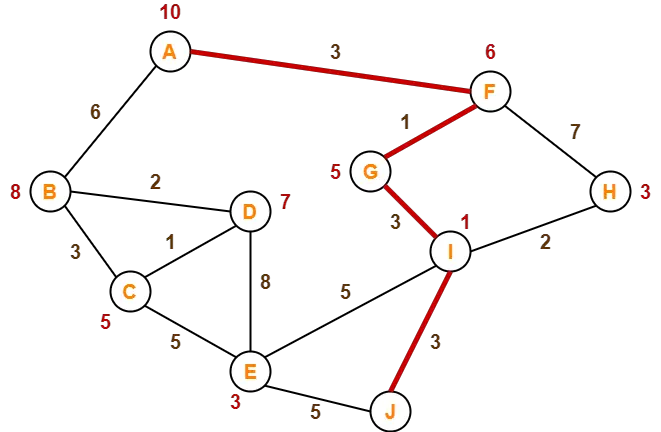

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/A_example_2_2.png', width = 600))

source: https://www.gatevidyalay.com/a-algorithm-a-algorithm-example-in-ai/

# B)

### Minimax Algorithm

1. **Algorithm**:
   - **Input**: Current game state.
   - **Output**: Best possible move for the current player.

2. **Steps**:
   - Perform a depth-first search of the game tree.
   - Alternately maximize and minimize outcomes:
     - **Maximize**: Choose the move that maximizes the score.
     - **Minimize**: Choose the move that minimizes the score.
   - Use an evaluation function at terminal states:
     - Assign scores: +1(positive) for win, -1(negative) for loss, 0 for draw.
   - **Backpropagate scores up the tree.**
   - Select the move leading to the highest score for the current player.

3. **Notes**:
   - Used in two-player games with alternating turns.
   - Assumes optimal play from both players.
   - Computationally expensive for large game trees.
   - Essential in game theory and AI for adversarial decision-making.

This algorithm ensures optimal decision-making in adversarial settings where players aim to **minimize their maximum possible loss**. It's foundational in game theory and AI for games like chess, tic-tac-toe, and more complex board games.

## Example 1

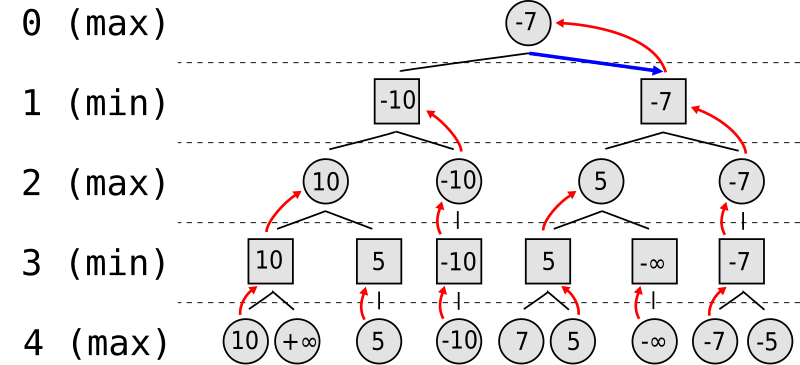

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/B_example_1_1.png', width = 800))

In [ ]:
adjacency_list = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': ['H', 'I'],
    'E': ['J'],
    'F': ['K', 'L'],
    'G': ['M'],
    'H': ['N', 'O'],
    'I': ['P'],
    'J': ['Q'],
    'K': ['R', 'S'],
    'L': ['T'],
    'M': ['U', 'V']
}

utility = {
    'N': 10,
    'O': float('inf'),
    'P': 5,
    'Q': -10,
    'R': 7,
    'S': 5,
    'T': float('-inf'),
    'U': -7,
    'V': -5,
}


### Explanation of the code below:

1. **Function Definition**:
   - `minimax(state, max_turn)`: This function takes two parameters:
     - `state`: The current state of the game.
     - `max_turn`: A boolean flag (`True` or `False`) indicating whether it's the maximizer's turn (`True`) or the minimizer's turn (`False`).

2. **Base Case**:
   - `if state not in adjacency_list:`: This condition checks if `state` is a terminal state (i.e., no further moves can be made). In such cases, the function returns the utility value of `state` directly from `utility[state]`. `utility[state]` is assumed to be a pre-defined function or lookup table that returns the utility value of the terminal state.

3. **Recursive Case**:
   - `possible_new_states = adjacency_list[state]`: Retrieves the list of possible states (or moves) that can be made from the current `state`.

4. **Decision Making**:
   - `if max_turn:`: This block is executed when it's the maximizer's turn. The maximizer seeks to maximize its utility. It does this by recursively calling `minimax` on each possible new state (`new_state`) with `max_turn=False` (indicating it's the minimizer's turn next). It collects the scores returned by these recursive calls in the list `scores` and returns the maximum score among them using `return max(scores)`.

   - `else:`: This block is executed when it's the minimizer's turn. The minimizer seeks to minimize the maximizer's utility (and thus maximize its own). It recursively calls `minimax` on each possible new state (`new_state`) with `max_turn=True` (indicating it's the maximizer's turn next). It collects the scores returned by these recursive calls in the list `scores` and returns the minimum score among them using `return min(scores)`.

### How it works:
- The algorithm starts from the initial state of the game (`state`) and decides the best move for the current player (`max_turn`).
- It recursively evaluates each possible move until it reaches a terminal state.
- At each level of recursion, the algorithm alternates between maximizing and minimizing player turns based on `max_turn`.
- The decisions are made based on the outcome (maximum or minimum score) of subsequent states until a terminal state is reached.

### Key Points:
- **Recursion**: The algorithm uses recursion to explore all possible future states of the game.
- **Maximization and Minimization**: Depending on whose turn it is (`max_turn`), the algorithm either maximizes or minimizes the score.
- **Terminal States**: The algorithm stops recursion and evaluates the utility of terminal states using `utility[state]`.
- **Depth of Recursion**: The depth of recursion depends on the complexity and branching factor of the game's state space.

This code snippet encapsulates the core of the minimax algorithm for game tree traversal and decision-making. It assumes the existence of `adjacency_list` to represent possible moves from each state and `utility` function/table to evaluate terminal states.

In [ ]:
def minimax(state, max_turn):
    if state not in adjacency_list:
        # We're at the end. Time to evaluate the state we're in
        return utility[state]

    possible_new_states = adjacency_list[state]

    if max_turn: # Is the current player the minimizer?
        scores = [
            minimax(new_state, max_turn=False)
            for new_state in possible_new_states
        ]
        return max(scores)
    else: # Or the maximizer?
        scores = [
            minimax(new_state, max_turn=True)
            for new_state in possible_new_states
        ]
        return min(scores)

In [ ]:
# Example 1:
minimax('A', True)

-7

source: https://en.wikipedia.org/wiki/Minimax

## Example 2

In [ ]:
adjacency_list = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': ['H', 'I'],
    'E': ['J', 'K'],
    'F': ['L', 'M'],
    'G': ['N', 'O'],
}

utility = {
    'H': -3,
    'I': 7,
    'J': 2,
    'K': -1,
    'L': -7,
    'M': -3,
    'N': 8,
    'O': 4,
}

In [ ]:
for i in range(1,7):
  display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/B_example_2_{i}.png'))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
minimax('A', True)

2

In [ ]:
minimax('A', False)

-1

# C)

### DFS

- Start at the root (or starting node).
- Go as deep as possible down one path.
- When you can't go further, backtrack to the last decision point and try another path.
- Repeat until you've explored all paths.

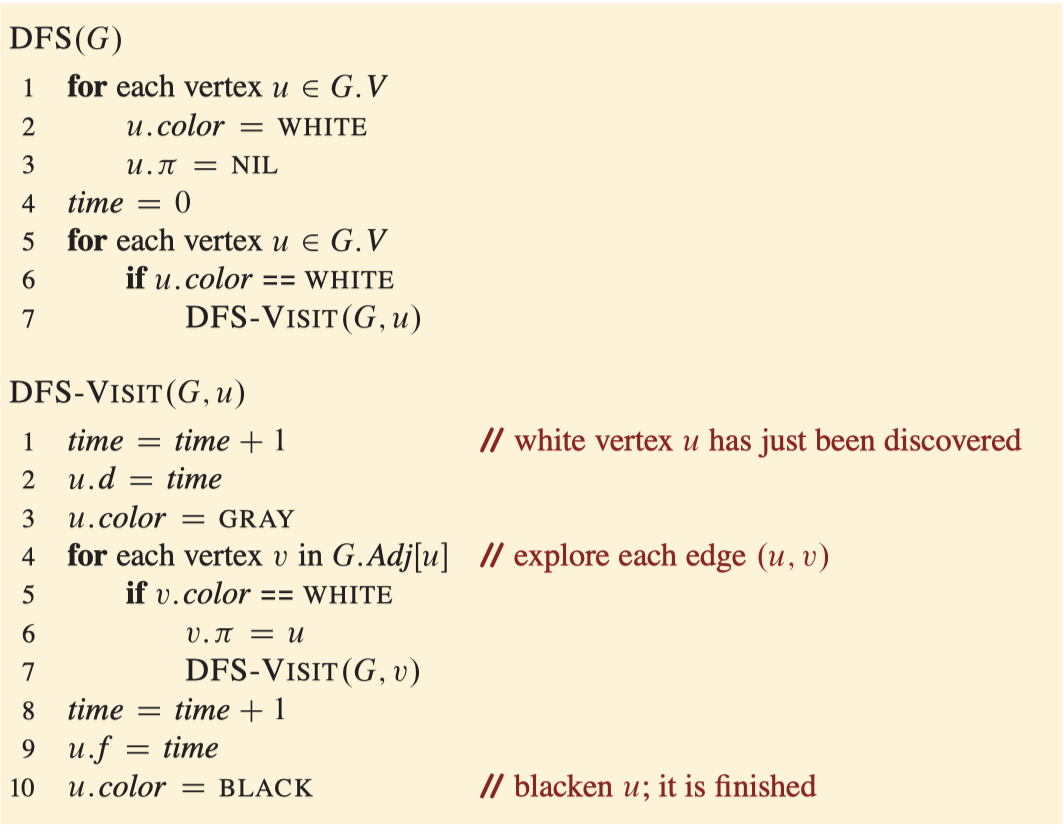

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/C_dfs_algorithm.png', width = 700))

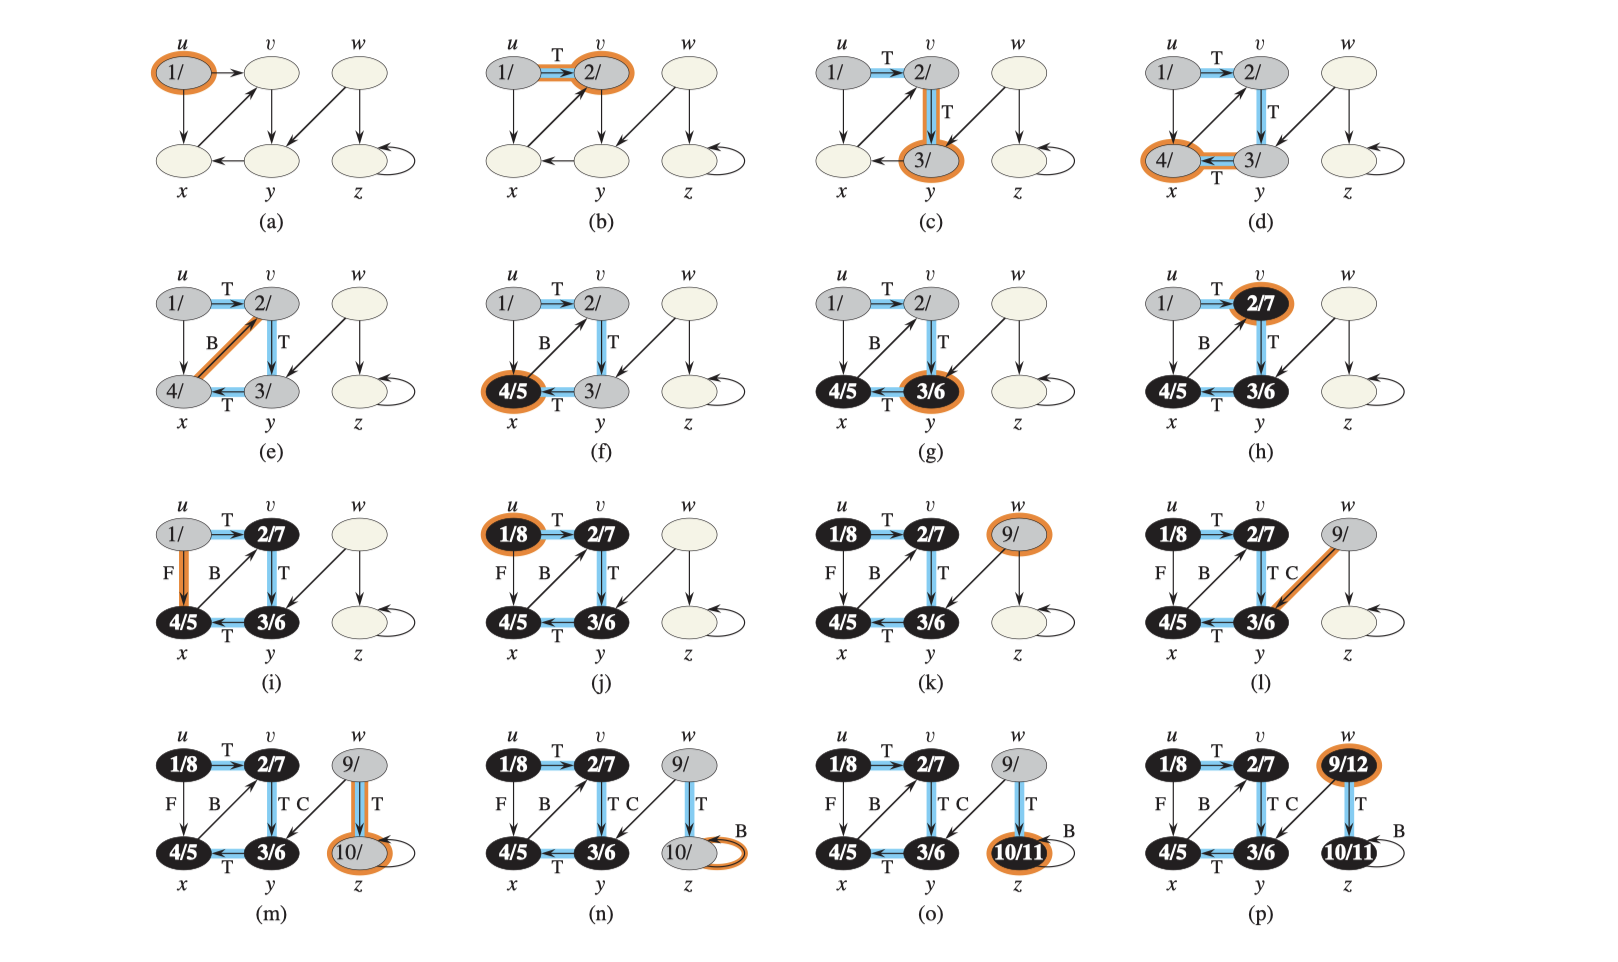

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/C_dfs_example.png', width = 1200))

In [ ]:
def dfs(adjacency_list, node, goal, frontier=[], reached=[]):
    if node == goal:
        return [node]

    frontier.append(node)
    reached.append(node)

    for neighbour in adjacency_list[node]:
        if neighbour not in reached:
            path = dfs(adjacency_list, neighbour, goal, frontier, reached)
            if path != None:
                return [node] + path

In [ ]:
adjacency_list = {
    'u': ['v', 'x'],
    'v': ['y'],
    'x': ['v'],
    'y': ['x'],
    'w': ['y', 'z'],
    'z': ['z'],
}

dfs(adjacency_list, 'u', 'x')

['u', 'v', 'y', 'x']

### BFS

- Start at the root (or starting node).
- Explore all the immediate neighbors.
- Move to the next level of neighbors.
- Continue this process until all nodes are explored.

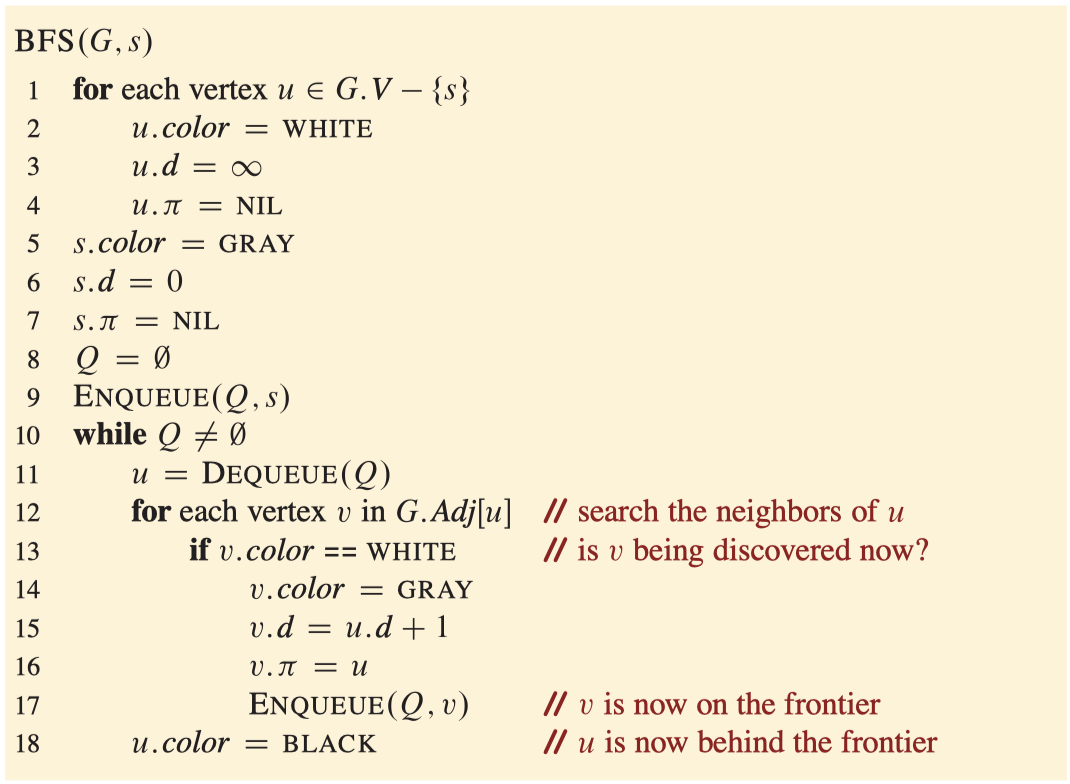

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/C_bfs_algorithm.png', width = 700))

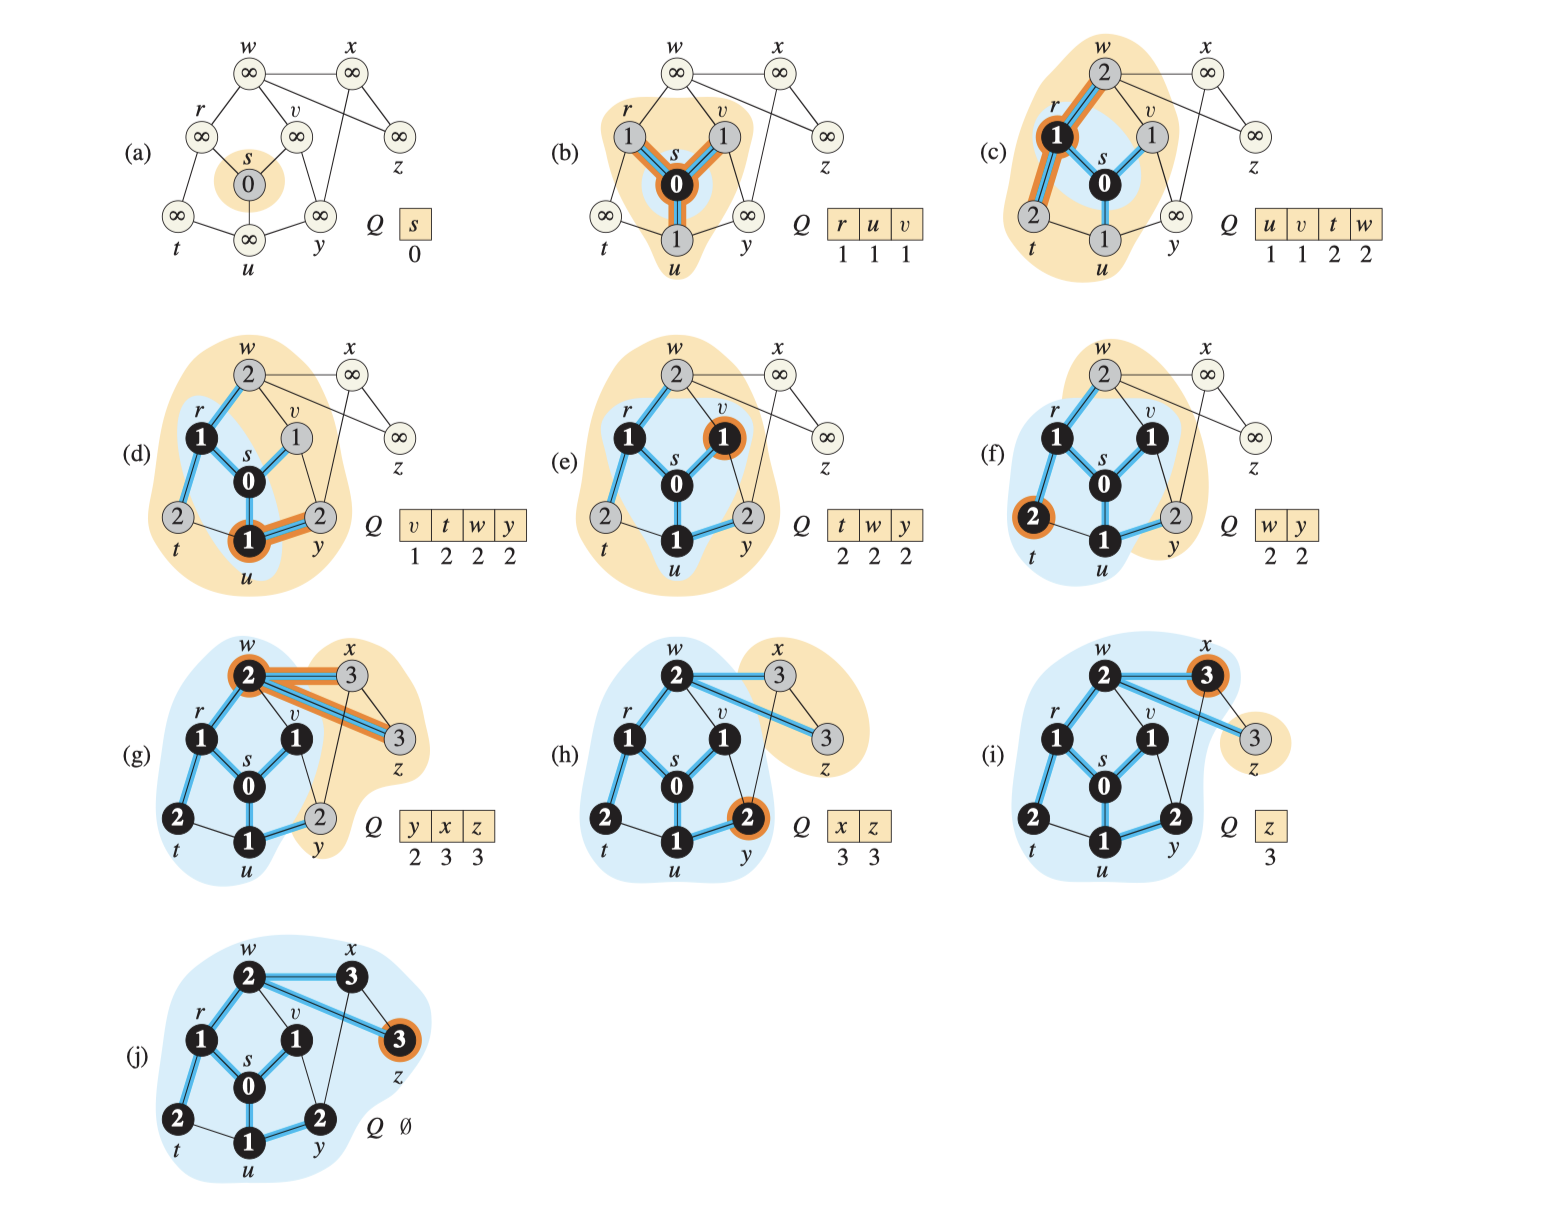

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/C_bfs_example.png', width = 1200))

In [ ]:
def bfs(adjacency_list, start, goal):
    frontier = [start]
    reached = [start]

    parent = {node : None for node in adjacency_list}
    parent[start] = start

    while frontier:
        print('Q', frontier)

        node = frontier.pop(0)

        if node == goal:
            return [node := parent[node] for _ in iter(lambda: parent[node] != node, False)][::-1] + [goal]

        for neighbour in adjacency_list[node]:
            if neighbour not in reached:
                reached.append(neighbour)
                frontier.append(neighbour)
                parent[neighbour] = node

In [ ]:
adjacency_list = {
    'R': ['S', 'T', 'W'],
    'S': ['R', 'U', 'V'],
    'T': ['R', 'U'],
    'U': ['S', 'T', 'Y'],
    'V': ['S', 'W', 'Y'],
    'W': ['R', 'V', 'X', 'Z'],
    'X': ['W', 'Y', 'Z'],
    'Y': ['U', 'V', 'X'],
    'Z': ['W', 'X']
}

path = bfs(adjacency_list, 'S', 'Z')
print('Path:', ' '.join(path))

Q ['S']
Q ['R', 'U', 'V']
Q ['U', 'V', 'T', 'W']
Q ['V', 'T', 'W', 'Y']
Q ['T', 'W', 'Y']
Q ['W', 'Y']
Q ['Y', 'X', 'Z']
Q ['X', 'Z']
Q ['Z']
Path: S R W Z


BFS and CFS examples are from CLRS-4th edition

### UCS

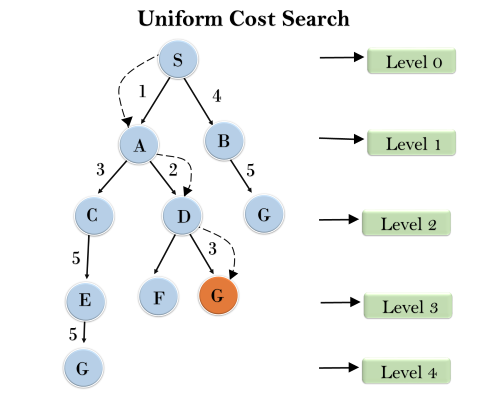

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/C_ucs_example.png', width = 700))

source: https://www.javatpoint.com/ai-uninformed-search-algorithms


### Function Breakdown

1. **Initialization**:
   - `frontier` is a priority queue (implemented using a heap) that stores nodes to be explored, prioritized by their cumulative path cost.
   - `explored` is a set that keeps track of nodes that have already been fully explored.
   - `predecessors` is a dictionary that maps each node to its predecessor, which will be used to reconstruct the path from the start node to the goal node.

```python
from heapq import heappush, heappop

def ucs(adjacency_list, start, goal):
    frontier = []
    explored = set()
    heappush(frontier, (0, start))
    predecessors = {start: None}
```

2. **Main Loop**:
   - The main loop continues until there are no more nodes to explore (i.e., `frontier` is empty).

```python
    while frontier:
```

3. **Expand Node with Lowest Cost**:
   - The node with the lowest cumulative path cost is removed from the frontier (priority queue).
   - If this node is the goal, reconstruct the path by following the `predecessors` dictionary from the goal back to the start.

```python
        cost, node = heappop(frontier)
        if node == goal:
            path = []
            while node is not None:
                path.append(node)
                node = predecessors[node]
            path.reverse()
            return cost, path
```

4. **Skip Already Explored Nodes**:
   - If the node has already been explored, skip it to avoid redundant work.

```python
        if node in explored:
            continue
```

5. **Explore Neighbors**:
   - For each neighbor of the current node, calculate the new path cost.
   - If the neighbor has not been explored or the new path cost is lower than a previously found path to this neighbor, update the neighbor's cost and add it to the frontier.
   - Update the `predecessors` dictionary to reflect the new path.

```python
        for neighbour, dist in adjacency_list[node]:
            if neighbour not in explored:
                heappush(frontier, (cost + dist, neighbour))
                if neighbour not in predecessors or cost + dist < cost:
                    predecessors[neighbour] = node
```

6. **Mark Node as Explored**:
   - Add the current node to the `explored` set to mark it as fully explored.

```python
        explored.add(node)
```

7. **Return None if No Path Found**:
   - If the frontier is empty and the goal has not been reached, return `None` to indicate that no path exists between the start and goal nodes.

```python
    return None
```


In [ ]:
from heapq import heappush, heappop

def ucs(adjacency_list, start, goal):
    frontier = []
    explored = set()
    heappush(frontier, (0, start))

    # Dictionary to keep track of the path
    predecessors = {start: None}

    while frontier:
        cost, node = heappop(frontier)
        if node == goal:
            # Reconstruct the path from start to goal
            path = []
            while node is not None:
                path.append(node)
                node = predecessors[node]
            path.reverse()
            return cost, path

        if node in explored:
            continue
        for neighbour, dist in adjacency_list[node]:
            if neighbour not in explored:
                heappush(frontier, (cost + dist, neighbour))
                # Update predecessor for path reconstruction
                if neighbour not in predecessors or cost + dist < cost:
                    predecessors[neighbour] = node

        explored.add(node)

    return None



In [ ]:
adjacency_list = {
    'S': [('A', 1), ('B', 4)],
    'A': [('C', 3), ('D', 2)],
    'B': [('G', 5)],
    'C': [('E', 5)],
    'D': [('G', 3), ('F', float('inf'))],
    'E': [('G', 5)],
    'F': [],
    'G': []
}

ucs(adjacency_list, 'S', 'G')

(6, ['S', 'A', 'D', 'G'])

# D)

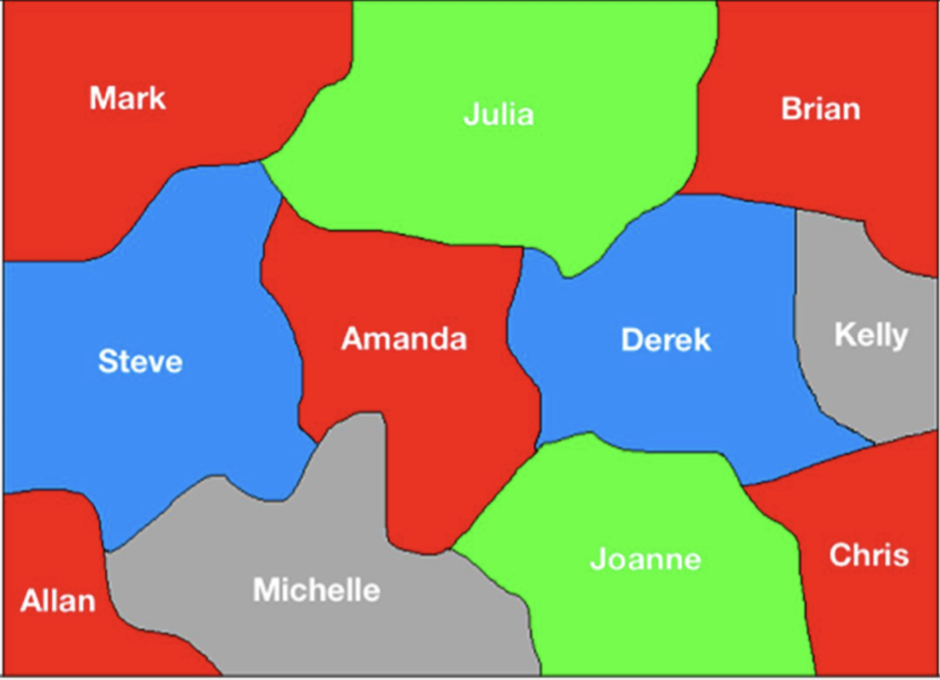

In [ ]:
display(Image(filename=f'/content/drive/MyDrive/Slides/Project3/D.png', width = 700))

In [ ]:
pip install simpleai -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.4/94.4 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from simpleai.search import CspProblem, backtrack

#### Simulate the figure with a graph such that each region is assigned to a unique vertex and two vertices have an edge between them if their regions are adjacent.

In [ ]:
vertices = ['Mark', 'Julia', 'Brian', 'Steve', 'Amanda', 'Derek', 'Kelly', 'Allan', 'Michelle', 'Joanne', 'Chris']

edges = [
    ('Mark', 'Julia'),
    ('Mark', 'Steve'),
    ('Julia', 'Steve'),
    ('Julia', 'Amanda'),
    ('Julia', 'Derek'),
    ('Julia', 'Brian'),
    ('Brian', 'Derek'),
    ('Brian', 'Kelly'),
    ('Steve', 'Amanda'),
    ('Steve', 'Allan'),
    ('Steve', 'Michelle'),
    ('Amanda', 'Derek'),
    ('Amanda', 'Michelle'),
    ('Amanda', 'Joanne'),
    ('Derek', 'Kelly'),
    ('Derek', 'Joanne'),
    ('Derek', 'Chris'),
    ('Kelly', 'Chris'),
    ('Allan', 'Michelle'),
    ('Michelle', 'Joanne'),
    ('Joanne', 'Chris')
]

#### Each vertex can different four colors

In [ ]:
domains = {vertex : ['red', 'green', 'blue', 'gray'] for vertex in vertices}

#### Define the simple constraint satisfaction problem as a graph with different colors for its adjacent vertices


### Explanation of the Code below

1. **Constraint Function**:

```python
def constraint_func(names, values):
    return values[0] != values[1]
```

- **Purpose**: This function defines a constraint that two values must be different.
- **Parameters**:
  - `names`: The names (or variables) involved in the constraint (not used in this simple function).
  - `values`: The values assigned to these variables.
- **Return**: `True` if the values are different, `False` otherwise.

2. **Constraints List**:

```python
constraints = [(edge, constraint_func) for edge in edges]
```

- **Purpose**: Create a list of constraints for the CSP.
- **`edges`**: A list of tuples representing pairs of variables that have constraints between them (e.g., edges in a graph coloring problem).
- **`constraint_func`**: The function to apply to each pair of variables.
- **Result**: A list of tuples where each tuple contains an edge and the constraint function.

3. **CSP Problem Definition**:

```python
problem = CspProblem(vertices, domains, constraints)
```

- **`vertices`**: The set of variables in the CSP (e.g., nodes in a graph).
- **`domains`**: The possible values for each variable.
- **`constraints`**: The list of constraints, as defined above.
- **`CspProblem`**: A class from a CSP library that defines the problem with given variables, domains, and constraints.




In [ ]:
def constraint_func(names, values):
    return values[0] != values[1]

constraints = [(edge, constraint_func) for edge in edges]

problem = CspProblem(vertices, domains, constraints)

#### Now, with our csp problem instantiated, Call the csp backtracking search algorithms

In [ ]:
backtrack(problem)

{'Mark': 'red',
 'Julia': 'green',
 'Brian': 'red',
 'Steve': 'blue',
 'Amanda': 'red',
 'Derek': 'blue',
 'Kelly': 'green',
 'Allan': 'red',
 'Michelle': 'green',
 'Joanne': 'gray',
 'Chris': 'red'}

help source: https://colab.research.google.com/drive/1sKWdhscgxCEqrmifWeWDsDsrAKkXeg1A#scrollTo=JiXRcT_CiaJb

Alireza Karimi

810101492